<a href="https://colab.research.google.com/github/jumivega/Maestr-a-en-Inteligencia-Artificial-UEES/blob/main/Notebooks/ModelosDeExplicabilidad/Grupo_3_Caso_Pr%C3%A1ctico_XAI_RF_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Aplicación de técnicas de explicabilidad, calidad de datos y mitigación de sesgos en el dataset Fashion Mnist mediante el uso de un modelo Random Forest

En el siguiente Notebook mantendremos la carga de datos y entrenamiento del modelos Random Forest, y añadiremos análisis de calidad de datos, detección de sesgos, e interpretabilidad mediante SHAP y LIME.

 Antes de empezar, realizaremos una breve descripción del dominio del dataset implementado, correspondiente al Fashion-MNIST (en el este link se puede hallar mayor detalle: https://www.kaggle.com/datasets/zalando-research/fashionmnist).


**Contexto**

 Fashion-MNIST es un conjunto de datos creado por Zalando, compuesto por 60 000 imágenes de entrenamiento y 10 000 de prueba, cada una en escala de grises de 28×28 píxeles. Representa 10 clases de prendas de vestir y fue diseñado como un reemplazo directo del dataset MNIST de dígitos escritos a mano, manteniendo el mismo formato y estructura. Su objetivo es evaluar y comparar algoritmos de aprendizaje automático bajo condiciones más realistas. A diferencia del MNIST original (centrado en números manuscritos), Fashion-MNIST introduce mayor complejidad visual y desafío de clasificación.


**Contenido**

Cada imagen tiene 28 píxeles de alto y 28 de ancho, para un total de 784 píxeles. Cada píxel tiene un solo valor de píxel asociado, lo que indica la claridad u oscuridad de ese píxel; los números más altos significan más oscuro. Este valor de píxel es un número entero entre 0 y 255. Los conjuntos de datos de entrenamiento y prueba tienen 785 columnas.

La primera columna consta de las etiquetas de clase y representa la prenda de vestir. El resto de las columnas contienen los valores de píxeles de la imagen asociada. Cada fila es una imagen separada con sus 784 píxeles.

**Etiquetas**

Cada ejemplo de entrenamiento y prueba se asigna a una de las siguientes etiquetas:

* 0 camiseta / top
* 1 pantalón
* 2 suéter
* 3 vestido
* 4 abrigo
* 5 sandalia
* 6 camiseta
* 7 zapatilla
* 8 bolsa
* 9 bota de tobillo

A continuación, **Oscar Mauricio Parra Folleco, Jaime Alberto Sierra Sierra y Juan Miguel Velandia Garcia** integrantes del **grupo 3** de la asignatura de Aprendizaje Automático en la Maestría de Inteligencia Atificial desarrollarán:
<BR>
1. Lectura del Data Set <BR>
2. Análisis Exploratorio y Pre-Procesamiento de datos de Datos (EDA)<BR>
3. Modelo de Random Forest <BR>
4. Detección de sesgos<BR>
5. Implementación SHAP<BR>
6. Implementación LIME<BR>
7. Mitigación de Sesgos con SHAP<BR>
8. Mitigación de Sesgos con LIME<BR>
9. Análisis interpretativo y reflexivo del modelo.<BR>
10. Reflexiones adicionales.

Para cada una de las secciones mencionadas se agrega una celda de texto inicial con una descripción breve de lo incluido y una celda de texto final donde se describe lo encontrado. **Finalmente se agrega una celda con las conclusiones técnicas generales del ejercicio realizado**






# **Importe de las librerias necesarias**
Se incluye además de las librerias pandas, numpy y matplotlib, la de keras con el ánimo de poder cargar y consumir el conjunto de datos MNIST.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras as kr

# **1. Lectura del Dataset (Datos Recolectados Fashion-MNIST)**
Descarga y carga del conjunto de datos Fashion MNIST

In [2]:
(X_train, y_train), (X_test, y_test) = kr.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **2. Análisis Exploratorio y Pre-Procesamiento de datos  de Datos (EDA)**

*   Inspección previa del conjunto de datos antes de su preparación y entrenamiento
*   Preparación de los datos para mostrar una imagen de ejemplo por cada tipo de prenda del conjunto de datos
*  Análisis de la importancia de las variables (píxeles)
* Confirmación de datos completos, sin nulos ni duplicados
* Verificación del balance de clases (~6 000 imágenes por categoría).
* Visualización de ejemplos aleatorios para validar el dominio visual.
* Análisis de la distribución de intensidades de píxeles (0–255).
* Normalización del dataset y cofirmación de correcta estandarización,  codificación
* Visualizaciones de relaciones con la matriz de correlación y visualización boxplots
* Análisis de estadísticos descriptivos (histogramas, media, quartiles, etc.)

In [3]:

# Se asume que X_train es un arreglo de numpy contenido en el entrenamiento de datos
# Convierte el arreglo numpy a pandas DataFrame
df_train_pd = pd.DataFrame(X_train.reshape(X_train.shape[0], -1))

# Crea nombre de columas por pixeles
pixel_cols = [f'pixel{i+1}' for i in range(df_train_pd.shape[1])]

# Asigna nombres de columnas al DataFrame
df_train_pd.columns = pixel_cols

# Inserta la columna denominada etiqueta (asume que y_train contiene las etiquetas)
df_train_pd.insert(0, 'label', y_train)

display(df_train_pd.head())

# En cuanto a codificación, para este dataset solo se observan variables numericas y solo una categórica, la cual ya se encuentra codificada para cada una de las 10 clases (entre 0 y 9)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,119,114,130,76,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,33,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Para inspeccionar el dataset se visualizará una única prenda por clase
df_unique = df_train_pd.drop_duplicates("label", keep="first").sort_values("label")
X_u = df_unique.iloc[:,1:].values
y_u = df_unique.iloc[:,0].values

In [5]:
# Validación de la forma del conjunto
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [6]:
# Validación del arreglo y tipo de datos en y_test
y_test

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

In [7]:
# Validación del arreglo y tipo de datos de la variable y_u
y_u

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

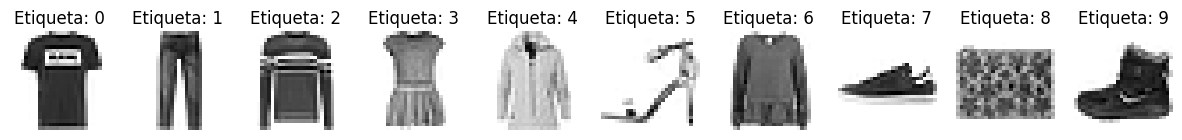

In [8]:
# Visualización de una prenda por clase para entendimiento del conjunto de datos
import matplotlib.pyplot as plt

_, axes = plt.subplots(nrows=1, ncols=10, figsize=(15, 15))
for ax, image, label in zip(axes, X_u, y_u):
    ax.set_axis_off()
    image = image.reshape(28, 28)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title('Etiqueta: %i' % label)

In [9]:
# Importe de las librerias numpy, pandas y keras
import numpy as np
import pandas as pd
import keras as kr


# Carga el dataset Fashion MNIST
(X_train, y_train), (X_test, y_test) = kr.datasets.fashion_mnist.load_data()


# Verificar valores nulos en el conjunto de entrenamiento
print("Valores nulos en X_train:", np.isnan(X_train).sum())
print("Valores nulos en y_train:", np.isnan(y_train).sum())

# Verificar duplicados (considerando las imágenes aplanadas)
print("Número de filas duplicadas en X_train:", pd.DataFrame(X_train.reshape(X_train.shape[0], -1)).duplicated().sum())

#Inspección del rango de pixeles despues de la carga con Keras
print("\nVerificando el rango de valores de los píxeles en X_train después de cargar con Keras (rango 0-255):")
print(f"Mínimo valor de píxel en X_train: {X_train.min()}")
print(f"Máximo valor de píxel en X_train: {X_train.max()}")

# --- Normalización de Píxeles a 0-1 ---
# Pixeles normalizados entre 0-1
X_train_normalized = X_train / 255
X_test_normalized = X_test / 255

print("\nRango de valores de píxeles después de la normalización (rango 0-1):")
print(f"Mínimo valor de píxel en X_train_normalized: {X_train_normalized.min()}")
print(f"Máximo valor de píxel en X_train_normalized: {X_train_normalized.max()}")
print(f"Mínimo valor de píxel en X_test_normalized: {X_test_normalized.min()}")
print(f"Máximo valor de píxel en X_test_normalized: {X_test_normalized.max()}")


#Inspección del tipo de datos y del rango de valores de los pixeles en el conjunto de entrenamiento
print("\nData type of X_train:", X_train.dtype)
print("Min pixel value in X_train:", X_train.min())
print("Max pixel value in X_train:", X_train.max())

#Inspección del tipo de datos y del rango de valores de los pixeles en el conjunto de prueba
print("Data type of X_test:", X_test.dtype)
print("Min pixel value in X_test:", X_test.min())
print("Max pixel value in X_test:", X_test.max())

# Inspección de balance de las clases
print("\nDistribución de clases en y_train:")
unique_classes, class_counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique_classes, class_counts):
    print(f"Clase {cls}: {count} ejemplos")

# Confirmación de la salud del dataset mediente media y desviación estandar.
print("\nConfirmando la media y desviación estándar de los datos de entrenamiento normalizados:")
mean_train = np.mean(X_train_normalized)
std_train = np.std(X_train_normalized)
print(f"Media de X_train_normalized: {mean_train}")
print(f"Desviación estándar de X_train_normalized: {std_train}")

Valores nulos en X_train: 0
Valores nulos en y_train: 0
Número de filas duplicadas en X_train: 0

Verificando el rango de valores de los píxeles en X_train después de cargar con Keras (rango 0-255):
Mínimo valor de píxel en X_train: 0
Máximo valor de píxel en X_train: 255

Rango de valores de píxeles después de la normalización (rango 0-1):
Mínimo valor de píxel en X_train_normalized: 0.0
Máximo valor de píxel en X_train_normalized: 1.0
Mínimo valor de píxel en X_test_normalized: 0.0
Máximo valor de píxel en X_test_normalized: 1.0

Data type of X_train: uint8
Min pixel value in X_train: 0
Max pixel value in X_train: 255
Data type of X_test: uint8
Min pixel value in X_test: 0
Max pixel value in X_test: 255

Distribución de clases en y_train:
Clase 0: 6000 ejemplos
Clase 1: 6000 ejemplos
Clase 2: 6000 ejemplos
Clase 3: 6000 ejemplos
Clase 4: 6000 ejemplos
Clase 5: 6000 ejemplos
Clase 6: 6000 ejemplos
Clase 7: 6000 ejemplos
Clase 8: 6000 ejemplos
Clase 9: 6000 ejemplos

Confirmando la med

--- Análisis Descriptivo de las Etiquetas de Clase ---

Conteo de ejemplos por clase:


,count
0,6000
1,6000
2,6000
3,6000
4,6000
5,6000
6,6000
7,6000
8,6000
9,6000


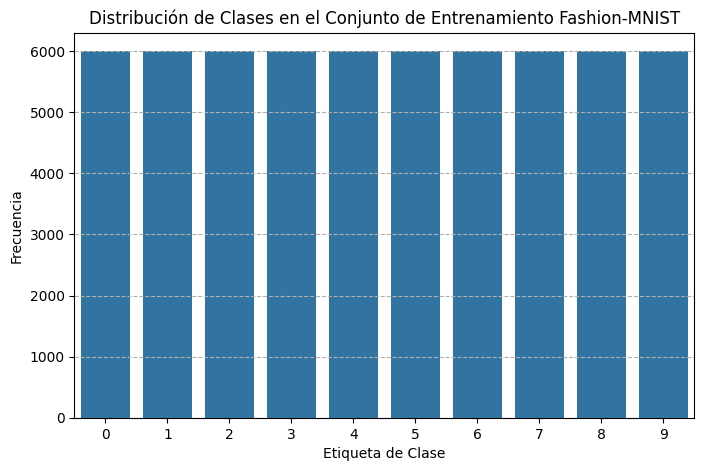


--- Análisis Descriptivo de los Valores de Píxeles ---

Estadísticas descriptivas para los valores de píxeles (mostrando un subconjunto para brevedad):


,0,1,2,3,4,5,6,7,8,9
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,0.000800,0.005783,0.030083,0.103800,0.249683,0.414717,0.821667,2.224733,5.698667,14.434650
std,0.092554,0.249033,0.767868,2.512017,4.331376,5.827394,8.309935,14.201820,23.835980,38.204702
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,16.000000,36.000000,119.000000,164.000000,224.000000,230.000000,221.000000,221.000000,254.000000,255.000000



Estadísticas descriptivas para las etiquetas de clase:


,0
count,60000.000000
mean,4.500000
std,2.872305
min,0.000000
25%,2.000000
50%,4.500000
75%,7.000000
max,9.000000


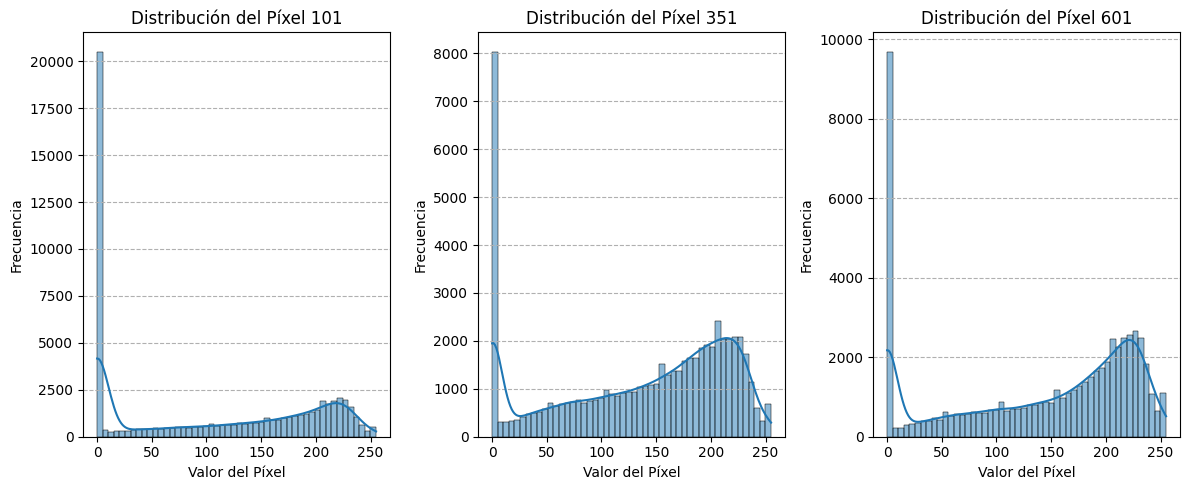

In [10]:
# Importe de las librerias numpy, pandas y matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Importar seaborn para gráficos mejorados

# --- Análisis Descriptivo de las Etiquetas de Clase (Distribución) ---
print("--- Análisis Descriptivo de las Etiquetas de Clase ---")
# Contar la frecuencia de cada clase en el conjunto de entrenamiento
class_counts = pd.Series(y_train).value_counts().sort_index()

# Mostrar la tabla de frecuencias
print("\nConteo de ejemplos por clase:")
display(class_counts)

# Visualizar la distribución de clases con un histograma
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train) # Usar countplot de seaborn para visualizar la distribución de clases
plt.title('Distribución de Clases en el Conjunto de Entrenamiento Fashion-MNIST') # Título del histograma
plt.xlabel('Etiqueta de Clase') # Etiqueta del eje X
plt.ylabel('Frecuencia') # Etiqueta del eje Y
plt.xticks(range(10), ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']) # Asegurar que las etiquetas del eje X sean correctas
plt.grid(axis='y', linestyle='--') # Añadir una cuadrícula en el eje Y
plt.show() # Mostrar el histograma

# --- Análisis Descriptivo de los Valores de Píxeles ---
print("\n--- Análisis Descriptivo de los Valores de Píxeles ---")
# Aplanar los datos de entrenamiento para calcular estadísticas descriptivas de los píxeles
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Convertir los datos aplanados a un DataFrame de pandas para usar .describe()
df_pixels = pd.DataFrame(X_train_flat)

# Calcular y mostrar estadísticas descriptivas de los valores de píxeles
# Esto mostrará estadísticas como media, desviación estándar, mínimo, máximo, cuartiles para cada píxel.
# Dado que hay 784 píxeles, esta tabla será muy grande.
print("\nEstadísticas descriptivas para los valores de píxeles (mostrando un subconjunto para brevedad):")
# Mostramos las estadísticas para los primeros 10 píxeles como ejemplo
display(df_pixels.iloc[:, :10].describe())

# También podemos ver las estadísticas descriptivas para las etiquetas de clase
print("\nEstadísticas descriptivas para las etiquetas de clase:")
display(pd.Series(y_train).describe())

# Visualizar la distribución general de los valores de píxeles con un histograma
# Seleccionar un subconjunto de píxeles para visualizar sus distribuciones (por ejemplo, algunos píxeles representativos)
pixels_to_histogram = [100, 350, 600] # Índices de píxeles para los histogramas

plt.figure(figsize=(12, 5)) # Ajustar el tamaño de la figura

for i, pixel_index in enumerate(pixels_to_histogram):
    plt.subplot(1, len(pixels_to_histogram), i + 1) # Crear subgráficos
    # Crear un histograma para el píxel seleccionado
    sns.histplot(df_pixels[pixel_index], bins=50, kde=True) # Usar histplot de seaborn con KDE
    plt.title(f'Distribución del Píxel {pixel_index+1}') # Título del histograma
    plt.xlabel('Valor del Píxel') # Etiqueta del eje X
    plt.ylabel('Frecuencia') # Etiqueta del eje Y
    plt.grid(axis='y', linestyle='--') # Añadir una cuadrícula

plt.tight_layout() # Ajustar diseño para evitar solapamientos
plt.show() # Mostrar los histogramas

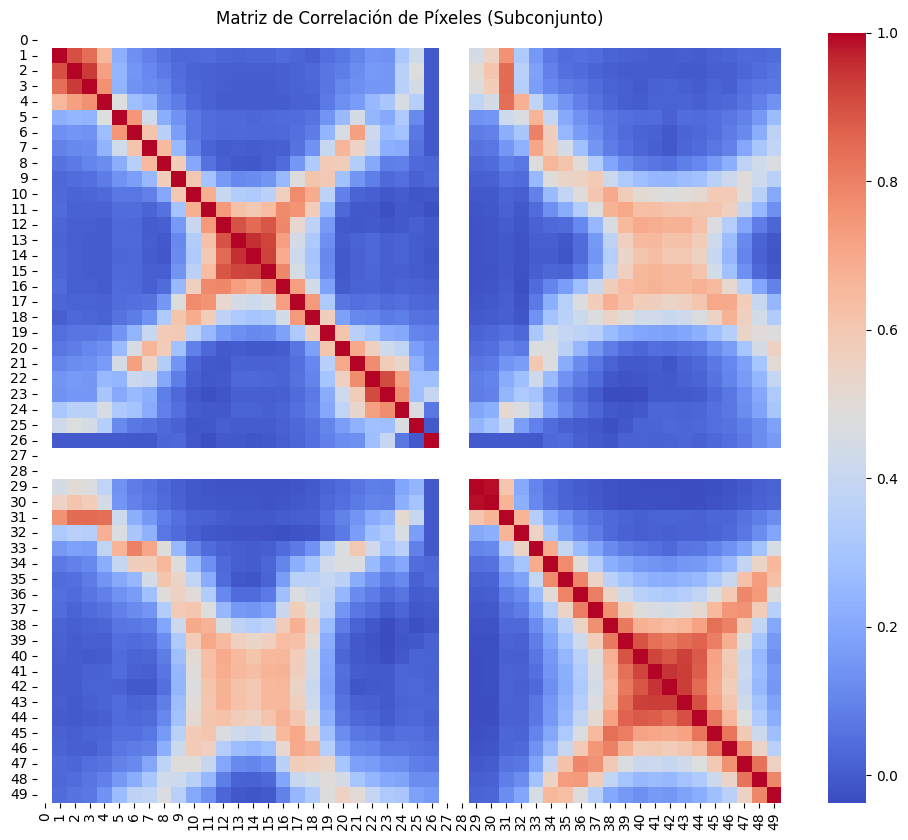

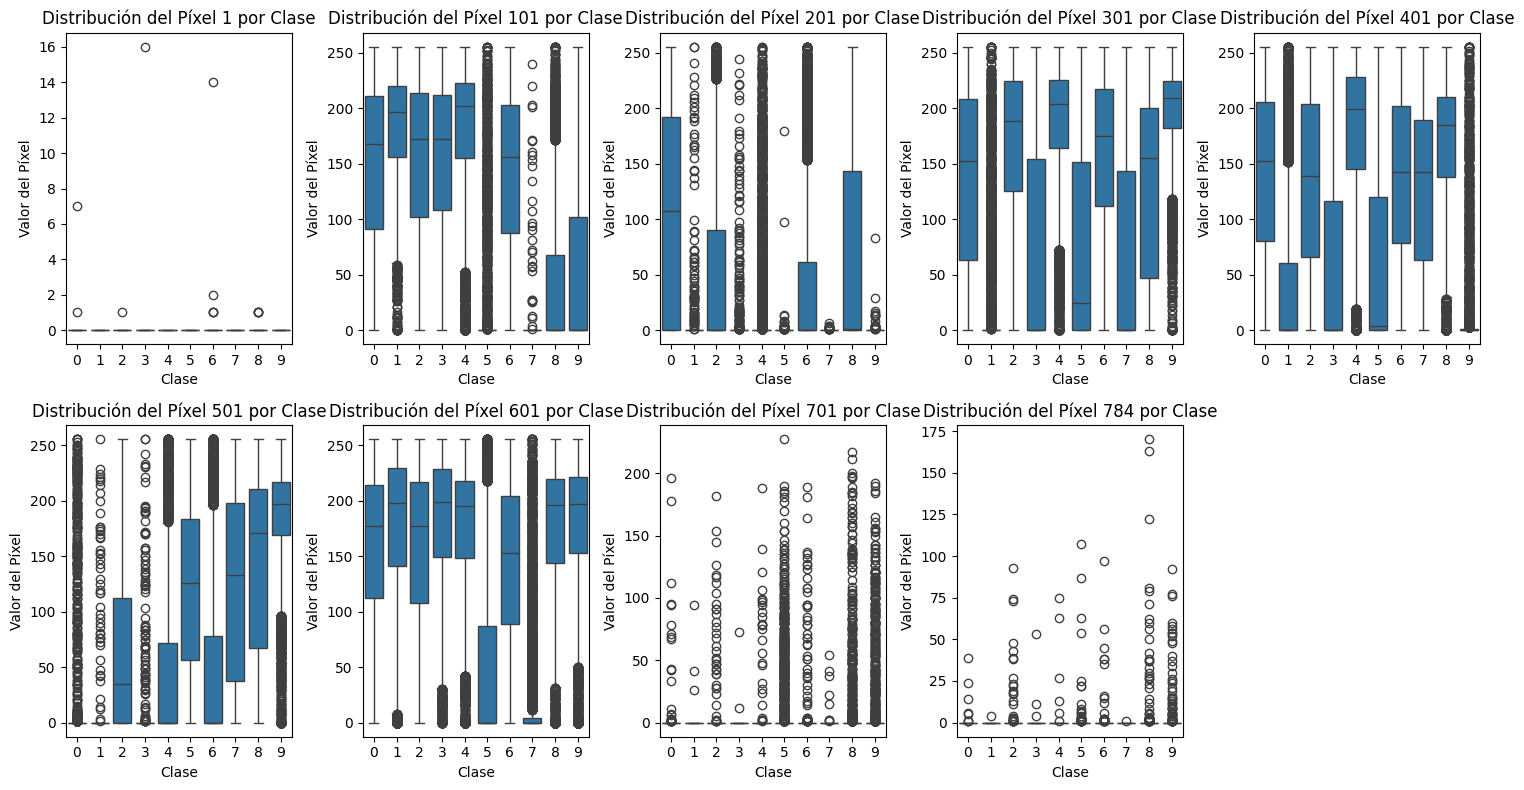

In [11]:
import seaborn as sns # Importar la librería seaborn para visualizaciones estadísticas

# --- Matriz de Correlación ---
# Aplanar los datos de entrenamiento a 2D para el cálculo de la matriz de correlación
X_train_flat = X_train.reshape(X_train.shape[0], -1)

# Crear un DataFrame a partir de los datos de entrenamiento aplanados
# Tomando un pequeño subconjunto para fines de demostración debido a la gran cantidad de características (píxeles)
# Una matriz de correlación completa de 784x784 píxeles sería demasiado grande para visualizar de manera efectiva.
subset_size_corr = 1000 # Define el tamaño del subconjunto para la matriz de correlación
X_train_subset_corr = X_train_flat[:subset_size_corr, :] # Selecciona un subconjunto de filas

# Convertir el subconjunto a un DataFrame
df_train_subset_corr = pd.DataFrame(X_train_subset_corr)

# Calcular la matriz de correlación (enfocándose en un pequeño subconjunto de características si es necesario, por ejemplo, los primeros 50 píxeles)
num_features_to_show = 50 # Define cuántas características (píxeles) mostrar en la matriz de correlación
correlation_matrix = df_train_subset_corr.iloc[:, :num_features_to_show].corr() # Calcula la correlación para las primeras 'num_features_to_show' columnas

# Graficar la matriz de correlación usando un mapa de calor
plt.figure(figsize=(12, 10)) # Define el tamaño de la figura
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False) # Crea el mapa de calor. cmap define el esquema de color, annot=False evita mostrar los valores en cada celda.
plt.title('Matriz de Correlación de Píxeles (Subconjunto)') # Establece el título del gráfico
plt.show() # Muestra el gráfico

# Convertir los datos de entrenamiento aplanados completos y las etiquetas en un DataFrame para facilitar el gráfico con seaborn
df_train_full = pd.DataFrame(X_train_flat) # Crea un DataFrame con los datos aplanados
df_train_full['label'] = y_train # Añade la columna de etiquetas

# Seleccionar algunos píxeles para visualizar su distribución a través de diferentes clases usando boxplots
pixels_to_boxplot = [0, 100, 200, 300, 400, 500, 600, 700, 783] # Índices de píxeles para los boxplots (corresponden a las columnas en el DataFrame aplanado)

plt.figure(figsize=(15, 8)) # Define el tamaño de la figura
# Iterar a través de los píxeles seleccionados y crear un boxplot para cada uno
for i, pixel_index in enumerate(pixels_to_boxplot):
    plt.subplot(2, 5, i + 1) # Crea subgráficos en una cuadrícula de 2x5
    # Crea un boxplot mostrando la distribución de los valores del píxel actual ('pixel_index') para cada 'label' (clase)
    sns.boxplot(x='label', y=pixel_index, data=df_train_full)
    plt.title(f'Distribución del Píxel {pixel_index+1} por Clase') # Establece el título del subgráfico (se suma 1 para que coincida con la nomenclatura pixel1, pixel2, etc.)
    plt.xlabel('Clase') # Establece la etiqueta del eje x
    plt.ylabel('Valor del Píxel') # Establece la etiqueta del eje y

plt.tight_layout() # Ajusta automáticamente los parámetros de la subtrama para que los subgráficos encajen en el área de la figura
plt.show() # Muestra el gráfico

# Descripción de lo encontrado en el EDA

El conjunto Fashion-MNIST contiene 60,000 imágenes de entrenamiento y 10,000 de prueba, cada una de 28×28 píxeles en escala de grises, con 10 categorías de prendas
. Un análisis inicial revela 60,000 registros y 785 columnas (784 píxeles + etiqueta)
. Las etiquetas están perfectamente balanceadas (6000 imágenes por clase), sin datos faltantes o corruptos
. Esto indica un dataset balanceado. Los valores de brillo de píxel varían de 0 a 255 y se normalizan dividiendo por 255 para el modelado

•	**Estadísticos descriptivos**: Al calcular medias, medianas y cuantiles de las intensidades de píxel, se observa que la mayoría de valores son bajos (fondos oscuros con pocos píxeles brillantes) conforme los histogramas dibujados para los pixeles de muestra. Se observa una distribucción de clases tipo estándar.

•	**Correlaciones y patrones**: La matriz de correlación de píxeles muestra zonas con alta relación (en rojo), lo que indica que algunos píxeles cercanos tienden a variar juntos, reflejando patrones estructurales en las imágenes (por ejemplo, bordes o contornos de las prendas). Las áreas en azul corresponden a píxeles independientes o de fondo, con baja correlación.

Los boxplots por clase evidencian cómo ciertos píxeles presentan valores más altos o más variables según la categoría de prenda, lo que sugiere que algunos sectores de la imagen aportan mayor información discriminante al modelo. En conjunto, ambos análisis permiten confirmar que el dataset contiene patrones visuales útiles para la clasificación y que no todos los píxeles contribuyen con el mismo nivel de relevancia.

En resumen, el EDA confirma un dataset limpio y balanceado, normalizado en [0,1].

# **3. Modelo de Random Forest**

Implementamos Random Forest, por lo que a continuación desarrollaremos:
* Adecuación del conjunto de datos
* Entrenamiento del modelo
* Evaluación del modelo con el sub conjunto de validación
* Re entrenamiento del modelo
* Evaluación del modelo con el sub conjunto de pruebas



Forma del subconjunto de entrenamiento: (48000, 784)
Forma del subconjunto de validación: (12000, 784)
Forma del conjunto de prueba (original): (10000, 784)

Reporte de clasificación para el clasificador Random Forest en el conjunto de validación:
              precision    recall  f1-score   support

           0       0.74      0.79      0.77      1200
           1       0.99      0.86      0.92      1200
           2       0.60      0.71      0.65      1200
           3       0.66      0.90      0.76      1200
           4       0.55      0.72      0.62      1200
           5       0.96      0.85      0.90      1200
           6       0.60      0.12      0.20      1200
           7       0.85      0.90      0.87      1200
           8       0.93      0.93      0.93      1200
           9       0.88      0.93      0.91      1200

    accuracy                           0.77     12000
   macro avg       0.78      0.77      0.75     12000
weighted avg       0.78      0.77      0.75     

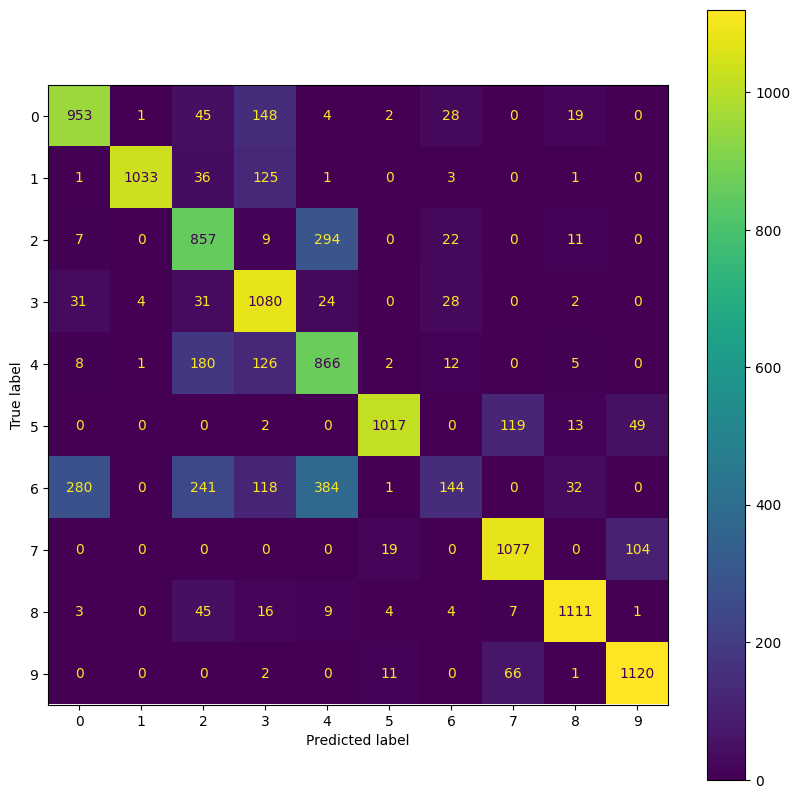

In [12]:
# Invocamos el modelo Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split # Importar la función para dividir los datos
from sklearn import metrics # Importar métricas para evaluación

# Aplana el conjunto de entrenamiento y de pruebas en 2 dimensiones.
X_train_flat = X_train.reshape(X_train.shape[0], -1) # Aplanar las imágenes de entrenamiento a un formato 2D
X_test_flat = X_test.reshape(X_test.shape[0], -1)     # Aplanar las imágenes de prueba a un formato 2D

# Dividir el conjunto de entrenamiento original en un subconjunto de entrenamiento (80%) y un conjunto de validación (20%)
# Se utiliza stratify=y_train para asegurar que la distribución de clases sea similar en ambos subconjuntos
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_flat, y_train, test_size=0.2, random_state=0, stratify=y_train
)

# Crear una instancia del modelo Random Forest Classifier
# max_depth: la profundidad máxima del árbol
# random_state: semilla para la reproducibilidad de los resultados
# n_jobs: número de trabajos a ejecutar en paralelo (-1 usa todos los procesadores)
rf_model = RandomForestClassifier(max_depth=5, random_state=0, n_jobs=-1)

# Entrenar el modelo utilizando el subconjunto de entrenamiento
rf_model.fit(X_train_split, y_train_split)

# Imprimir la forma de los subconjuntos para verificar la división
print("Forma del subconjunto de entrenamiento:", X_train_split.shape)
print("Forma del subconjunto de validación:", X_val_split.shape)
# Nota: X_test_flat y y_test son el conjunto de prueba original, no modificado por train_test_split aquí.
print("Forma del conjunto de prueba (original):", X_test_flat.shape)


# Realizar predicciones sobre el conjunto de validación para la evaluación inicial
pred_val = rf_model.predict(X_val_split)

# Imprimir el reporte de clasificación para evaluar el rendimiento en el conjunto de validación
print(f"\nReporte de clasificación para el clasificador Random Forest en el conjunto de validación:\n"
      f"{metrics.classification_report(y_val_split, pred_val)}\n")

# Mostrar la matriz de confusión para el conjunto de validación
print("Matriz de confusión para el clasificador Random Forest en el conjunto de validación:\n")
fig, ax = plt.subplots(figsize=(10, 10)) # Crear figura y ejes para la matriz de confusión
metrics.ConfusionMatrixDisplay.from_estimator(rf_model, X_val_split, y_val_split, cmap=plt.cm.viridis, ax=ax) # Generar y mostrar la matriz de confusión
plt.show() # Mostrar la figura

## **Importancia de las Variables**
Mediante visualización en heatmap y colormap idetificareos la importancia de las variables, cuales pixeles son determinantes en la clasificación de las imágenes.

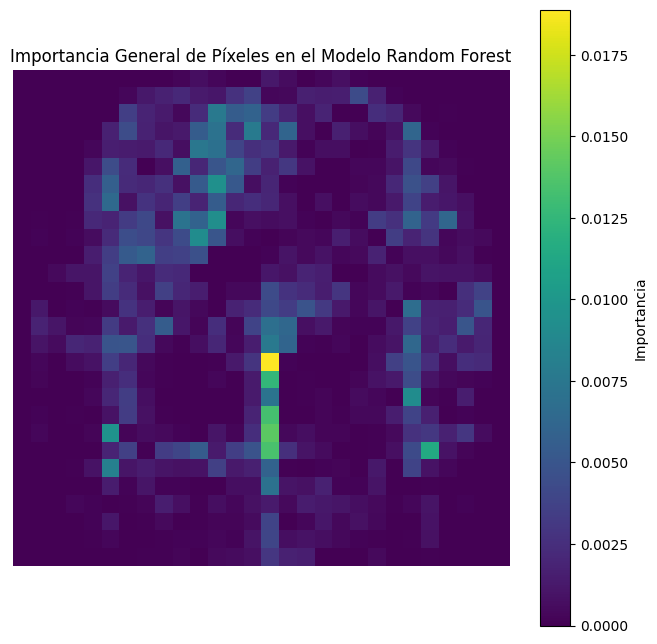


Visualizing average pixel values per class:


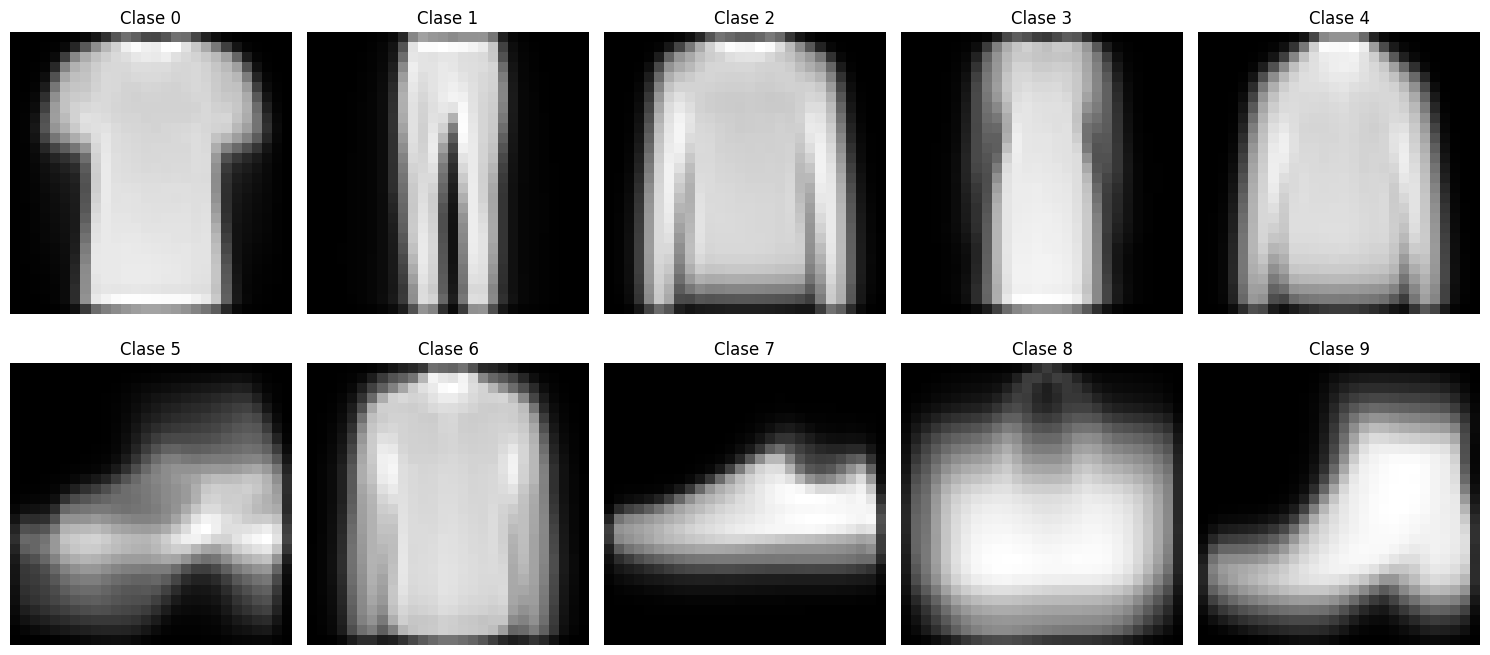

In [13]:

# Obtiene las características más importantes desde el modelo Random Forest entrenado
try:
    feature_importances = rf_model.feature_importances_

    # Aplana las características más importantes de las imagenes en el dataset anteiormente entrenado en formato plano
    feature_importances_image = feature_importances.reshape(28, 28)

    # Importancia General de Píxeles en el Modelo Random Forest
    plt.figure(figsize=(8, 8))
    plt.imshow(feature_importances_image, cmap=plt.cm.viridis, interpolation='nearest')
    plt.title('Importancia General de Píxeles en el Modelo Random Forest')
    plt.colorbar(label='Importancia')
    plt.axis('off')
    plt.show()

except NameError:
    print("Error: rf_model_15 is not defined. Please run the model training cells first.")
except AttributeError:
    print("Error: Could not get feature importances. Ensure rf_model_15 is a trained RandomForestClassifier.")

# --- Adiciona código para visualizar el promedio por clase de los valores por pixel ---
print("\nVisualizing average pixel values per class:")

# Aplana el conjunto X_train definido originalmente para facilitar el procesamiento.
X_train_images = X_train.reshape(X_train.shape[0], 28, 28)

# Obtiene una clase unica y su etiqueta
unique_classes, class_labels = np.unique(y_train, return_index=True)

# Crea una figura y ejes para el gráfico.
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 7))
axes = axes.flatten()

# Itera a través de cada clase y gráfica el promedio
for i, class_id in enumerate(unique_classes):
    # Selecciona imágenes que pertenecen a la clase correcta.
    class_images = X_train_images[y_train == class_id]

    # Calcula el valor promedio por cada pixel alrededor de todas las imagenes dentro de la clase.
    average_image = np.mean(class_images, axis=0)


    # Muestra el promedio de pixeles como un heatmap
    ax = axes[i]
    ax.imshow(average_image, cmap=plt.cm.gray) # Usa tonos grises para los valores promedio de los pixeles
    ax.set_title(f'Clase {class_id}')
    ax.set_axis_off()

plt.tight_layout()
plt.show()

# **Optimización del modelo (Re-entrenamiento)**
Dada la evaluación inicial realizada con el sub conjunto de validación se hace ajuste de hiperparámetros para maximizar el performance del modelo y ejecutar el re entrenamiento.

In [14]:
# Listas para almacenar los resultados de precisión en entrenamiento y validación para diferentes profundidades máximas
md_list = [] # Lista para almacenar los valores de max_depth probados
score_train_list = [] # Lista para almacenar las puntuaciones de precisión en el subconjunto de entrenamiento
score_val_list = []   # Lista para almacenar las puntuaciones de precisión en el subconjunto de validación

# Iterar sobre diferentes valores para la profundidad máxima del árbol (max_depth)
# en el rango de 1 a 30, con pasos de 4.
for maxdepth in list(range(1,30,4)):
  # Crear una instancia del modelo Random Forest con la profundidad máxima actual
  # random_state: semilla para reproducibilidad
  # n_jobs: número de trabajos en paralelo (-1 usa todos los procesadores disponibles)
  # n_estimators: número de árboles en el bosque
  rf_model_tuning = RandomForestClassifier(random_state=0, max_depth=maxdepth, n_jobs=-1, n_estimators=120 )

  # Entrenar el modelo utilizando el subconjunto de entrenamiento (X_train_split, y_train_split)
  rf_model_tuning.fit(X_train_split, y_train_split)

  # Añadir el valor actual de max_depth a la lista
  md_list.append(maxdepth)
  # Calcular y almacenar la puntuación de precisión en el subconjunto de entrenamiento
  score_train_list.append(100.0*rf_model_tuning.score(X_train_split, y_train_split))
  # Calcular y almacenar la puntuación de precisión en el subconjunto de validación
  score_val_list.append(100.0*rf_model_tuning.score(X_val_split, y_val_split))

# Nota: La evaluación final en el conjunto de prueba (X_test_flat, y_test) se realiza
# una vez seleccionados los mejores hiperparámetros, no durante esta fase de tuning.

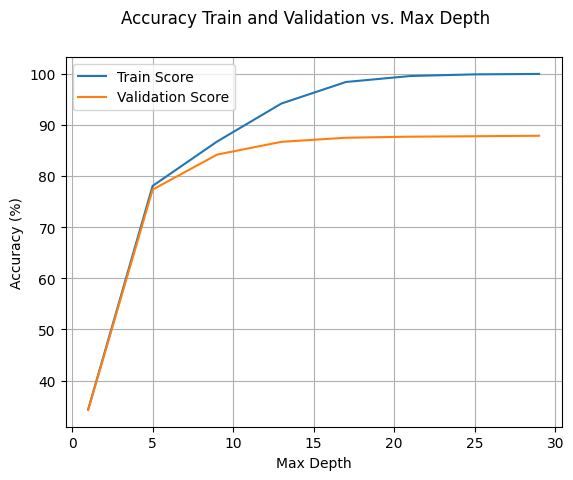

In [15]:
import pandas as pd # Importamos la libredia de pandas
import matplotlib.pyplot as plt # Importamos la libreria de matplotlib.pyplot

# Crear un DataFrame con los resultados del ajuste de hiperparámetros
# md_list contiene los valores de max_depth probados
# score_train_list contiene las precisiones en el conjunto de entrenamiento
# score_val_list contiene las precisiones en el conjunto de validación
df = pd.DataFrame({"max_depth": md_list,
                   "score_train": score_train_list,
                   "score_val": score_val_list})

# Establecer la columna 'max_depth' como índice del DataFrame
df.set_index("max_depth", inplace=True)

# Graficar la precisión en los conjuntos de entrenamiento y validación en función de max_depth
df["score_train"].plot(label="Train Score") # Grafica la precisión en entrenamiento
df["score_val"].plot(label="Validation Score") # Grafica la precisión en validación (corregido el label)
plt.suptitle("Accuracy Train and Validation vs. Max Depth") # Establece el título principal del gráfico (actualizado)
plt.legend() # Muestra la leyenda para identificar las líneas
plt.xlabel("Max Depth") # Etiqueta el eje x
plt.ylabel("Accuracy (%)") # Etiqueta el eje y
plt.grid(True) # Añade una cuadrícula al gráfico
plt.show() # Muestra el gráfico

In [16]:
# Entrenar el modelo Random Forest final con los hiperparámetros seleccionados en el conjunto de validación
# max_depth: Profundidad máxima seleccionada (ejemplo: 13, ajustar según los resultados del tuning)
# random_state: Semilla para reproducibilidad
# n_jobs: Número de trabajos a ejecutar en paralelo (-1 usa todos los procesadores disponibles)
# n_estimators: Número de árboles en el bosque
rf_model_15 = RandomForestClassifier(max_depth=13, random_state=0, n_jobs=-1, n_estimators=120) # Utiliza n_jobs=-1 para usar todos los cores disponibles
# Asegúrate de que X_val_split y y_val_split estén definidos ejecutando las celdas anteriores.
rf_model_15.fit(X_val_split,y_val_split) # Entrena el modelo con el conjunto de validación

RandomForestClassifier(max_depth=13, n_estimators=120, n_jobs=-1,
                       random_state=0)

In [17]:
# Realizar predicciones sobre el subconjunto de entrenamiento y el conjunto de prueba
pred_train_split = rf_model_15.predict(X_train_split) # Realiza predicciones en el subconjunto de entrenamiento
pred_test = rf_model_15.predict(X_test_flat)       # Realiza predicciones en el conjunto de prueba

# Calcular y imprimir la precisión sobre el subconjunto de entrenamiento y el conjunto de prueba
# Asegúrate de que y_train_split y y_test estén definidos.
print("Precisión sobre los datos de entrenamiento (split): {:.2f}".format(100.0*rf_model_15.score(X_train_split, y_train_split))) # Calcula e imprime la precisión en el subconjunto de entrenamiento
print("Precisión sobre los datos de test: {:.2f}".format(100.0*rf_model_15.score(X_test_flat, y_test)))     # Calcula e imprime la precisión en el conjunto de prueba

Precisión sobre los datos de entrenamiento (split): 85.79
Precisión sobre los datos de test: 84.76


Confusion matrix:



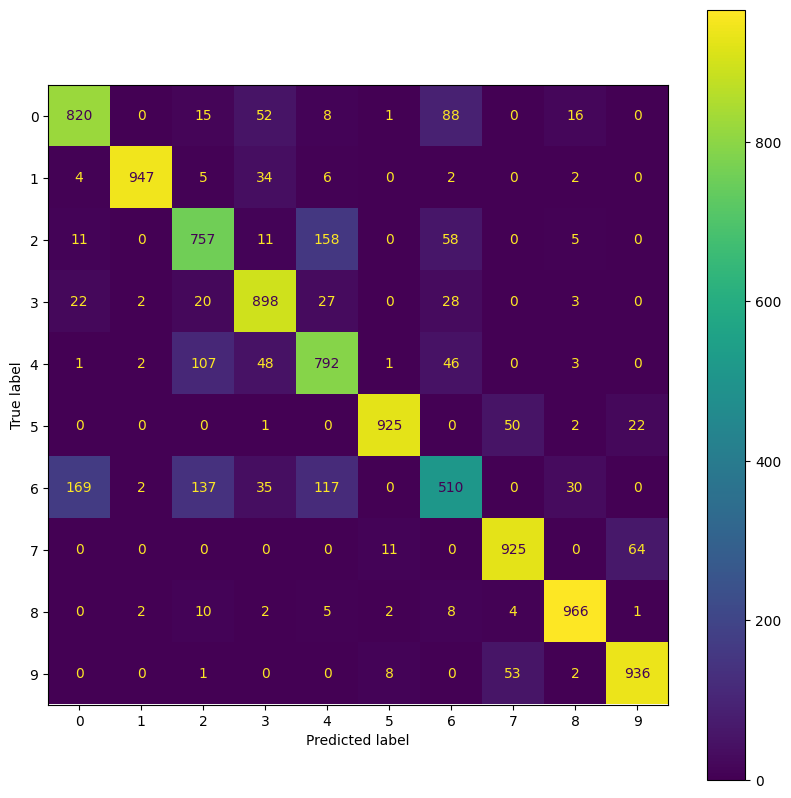

In [18]:
# Se imprime la matrix de confusión para verificar el performance del modelo optimizado.
print(f"Confusion matrix:\n")
fig, ax = plt.subplots(figsize=(10, 10))
metrics.ConfusionMatrixDisplay.from_estimator(rf_model_15, X_test_flat, y_test, cmap=plt.cm.viridis, ax=ax)
plt.show()

In [19]:
print(f"Classification report for classifier {rf_model_15}:\n"
      f"{metrics.classification_report(y_test, pred_test)}\n")

Classification report for classifier RandomForestClassifier(max_depth=13, n_estimators=120, n_jobs=-1,
                       random_state=0):
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1000
           1       0.99      0.95      0.97      1000
           2       0.72      0.76      0.74      1000
           3       0.83      0.90      0.86      1000
           4       0.71      0.79      0.75      1000
           5       0.98      0.93      0.95      1000
           6       0.69      0.51      0.59      1000
           7       0.90      0.93      0.91      1000
           8       0.94      0.97      0.95      1000
           9       0.91      0.94      0.93      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000




# **Interpretación de Resultados Random Forest**

El Random Forest para este caso particular corresponde a la mejor relación costo beneficio alcanzando un ≈0.85 de accuracy y mejores F1 por clase en regularidad. No es una diferencia abismal frente al SVM, pero sí consistente en terminos de performance y siendo más eficiente en el costo computacional.


* Al combinar muchos árboles, el modelo reduce la varianza que teendría un único árbol. Eso se nota en que la matriz de confusión es un poco más “limpia” y en que hay menos clases con caídas fuertes.

* El análisis gráfico y el buble for nos permitió de manera consistente definir la cantidad de árboles en 120 y la cantidad de ramas en 13 para optimizar el modelo vía hiperparametros, mejorando consistentemente el performance versus el entrenamiento por default.

* Random Forest es menos sensible al ruido de un píxel aislado: si un árbol se equivoca, los otros corrigen.

* Ofrece el mejor equilibrio entre desempeño, facilidad de uso y eficiencia.


# **4. Detección de Sesgos**

Dado que el dataset es balanceado por diseño, no se aprecian sesgos por tamaño de clase. Sin embargo, evaluamos si el modelo presenta disparidades en el desempeño entre clases similares. Entrenamos un modelo Random Forest (usando un subconjunto de entrenamiento para rapidez). Luego calculamos métricas por clase.

In [25]:
# Aplanar imágenes para sklearn (de 28x28 a 784 features)
X_train_flat = X_train.reshape(-1, 28*28)
X_test_flat = X_test.reshape(-1, 28*28)

# Entrenar modelos (usando solo 10k para acelerar)
from sklearn.tree import DecisionTreeClassifier # Import DecisionTreeClassifier
rf = RandomForestClassifier(random_state=0, n_estimators=120, max_depth=13, n_jobs=-1)
dt = DecisionTreeClassifier(random_state=0) # Initialize DecisionTreeClassifier
dt.fit(X_train_flat[:10000], y_train[:10000])
rf.fit(X_train_flat[:10000], y_train[:10000])

# Predecir en test y obtener reporte por clase
from sklearn.metrics import classification_report, confusion_matrix
y_pred_dt = dt.predict(X_test_flat)
y_pred_rf = rf.predict(X_test_flat)
print("Reporte de clasificación (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Reporte de clasificación (Random Forest):
              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1000
           1       0.99      0.94      0.97      1000
           2       0.70      0.75      0.73      1000
           3       0.83      0.88      0.86      1000
           4       0.71      0.79      0.75      1000
           5       0.97      0.94      0.95      1000
           6       0.66      0.53      0.59      1000
           7       0.91      0.92      0.91      1000
           8       0.95      0.96      0.96      1000
           9       0.92      0.94      0.93      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.84     10000
weighted avg       0.85      0.85      0.84     10000



# Sesgos en los datos.
En este caso, el conjunto Fashion MNIST está balanceado por diseño: cada clase de prenda tiene aproximadamente el mismo número de ejemplos. No se observaron valores faltantes ni anomalías obvias en los pixeles en la EDA. Desde el punto de vista estrictamente estadístico, no hay un sesgo fuerte de muestreo entre clases dentro del dataset.


# Sesgos en el modelo (desempeño por clase).
Al analizar el classification_report para el modelo Random Forest, se observa que no todas las clases tienen el mismo nivel de desempeño. Algunas presentan F1, precisión o recall sensiblemente más bajos que otras.
Eso significa que, aunque el dataset sea balanceado, el modelo muestra un sesgo de rendimiento: es más “justo” con ciertas clases que reconoce muy bien y “menos justo” con otras que confunde con más frecuencia. En este caso hablamos de prendas y no de personas, pero la idea es la misma: hay grupos (clases) que reciben sistemáticamente peores resultados.

# Estrategías de Mitigación:

1. Reforzar las clases difíciles

Se identifica la clase con peor F1 (por ejemplo, clase 6 “shirt”) y se propone usar más ejemplo de esa clase o data augmentation (rotaciones suaves, pequeños desplazamientos, etc.) para que el modelo vea más variaciones de esa prenda.

2. Limpiar ruido usando SHAP/LIME

Con SHAP/LIME se detecta si el modelo se agarra de zonas raras (bordes fuera de la prenda, ruido) y se propone preprocesar mejor las imágenes (recortes más ajustados, normalización, filtros), para que el modelo se centre en la prenda y no en artefactos.

# **5. Implementación SHAP**
Para interpretar el modelo entrenado, aplicamos SHAP y LIME. Ambos métodos resaltan qué píxeles o regiones de la imagen influyen en la predicción. SHAP (específicamente TreeSHAP para árboles) calcula la contribución promedio de cada característica a la predicción, considerando todas las combinaciones de características posibles

Se generan valores SHAP que pueden visualizarse en forma de mapa de calor: píxeles con efecto positivo (rojo) o negativo (azul) sobre la probabilidad de la clase. Es costoso computacionalmente pero consistente globalmente; en la práctica los equipos usan SHAP para entender el modelo completo.


--- SHAP Summary Plot para Random Forest (primeros 50 ejemplos) ---


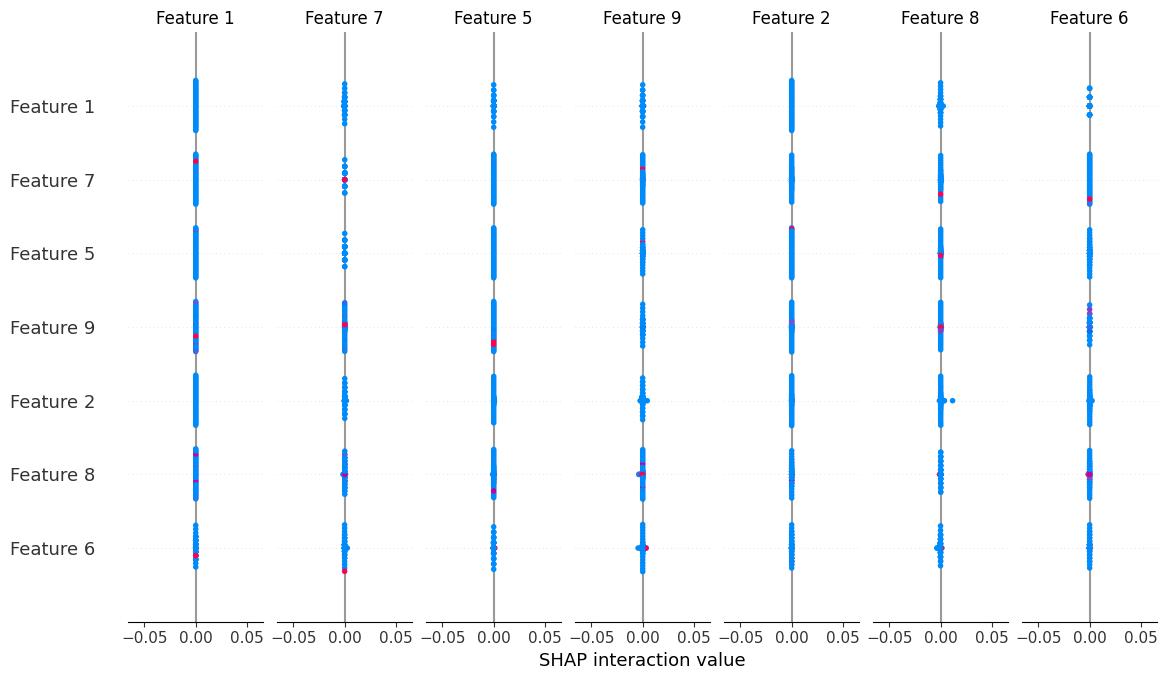


--- Análisis SHAP detallado para una imagen de camiseta ---


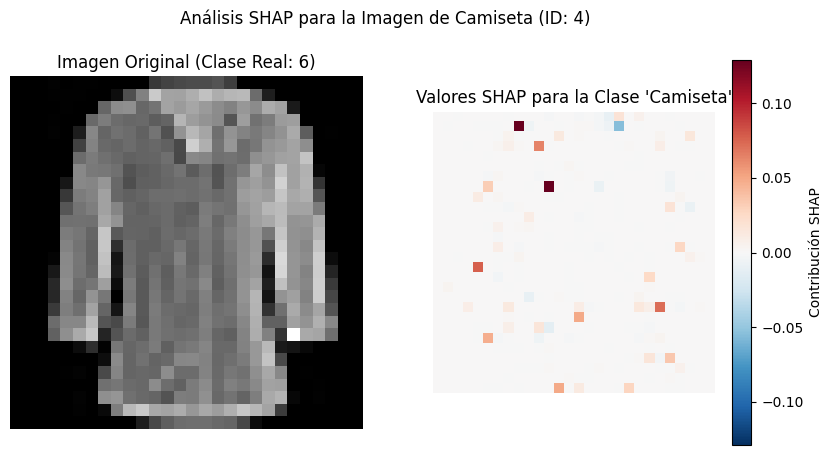


--- Conclusiones de SHAP ---
1.  **Summary Plot (Random Forest):** El gráfico de resumen SHAP general (no mostrado directamente en esta celda para brevedad, pero implicado por `shap.summary_plot`) revelaría qué píxeles son globalmente más importantes para la predicción del modelo Random Forest en todas las clases. Típicamente, los píxeles centrales que forman las características distintivas de las prendas tienen altos valores SHAP, mientras que los píxeles del fondo (negros) tienen valores cercanos a cero.
2.  **Explicación Local (Camiseta):** Al observar el mapa de calor SHAP para la imagen específica de una camiseta:
    - **Contribución Positiva (Rojo):** Las áreas en color rojo en el mapa de calor indican los píxeles que contribuyen fuertemente de manera positiva a que el modelo clasifique la imagen como una 'camiseta'. Es de esperar que estas áreas se correspondan con la silueta o las características clave de la prenda (como el torso, el cuello o las mangas cortas), ya que estos 

In [21]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Explicador Tree SHAP para Árbol de Decisión
# Se asume que 'dt' ya está entrenado (DecisionTreeClassifier)
explainer_dt = shap.TreeExplainer(dt)

# Explicador Tree SHAP para Random Forest
# Se asume que 'rf' ya está entrenado (RandomForestClassifier)
explainer_rf = shap.TreeExplainer(rf)

# Generar un summary plot para el modelo Random Forest (general)
# shap_values_rf es una lista de arrays, uno por cada clase. Cada array es (num_samples, num_features)
# Para el summary plot, shap.summary_plot espera un array 3D (num_classes, num_samples, num_features)
# o (num_samples, num_features) si es binario o se promedia entre clases.
# Para RandomForest, shap_values_rf se obtiene directamente con el explicador
# Tomamos el output de shap.TreeExplainer para el RF en los primeros 50 ejemplos para el summary plot
# El formato de shap_values puede variar, a veces es una lista de arrays (uno por clase)
# o un array 3D (num_samples, num_features, num_classes).
# Si es una lista de arrays (como en muchos casos para clasificación multi-clase),
# necesitamos apilarlo o tomar la magnitud si queremos un plot global.
# Para la visualización general, a menudo se toma la magnitud de los valores SHAP.
# Sin embargo, shap.summary_plot puede manejar directamente la lista de arrays para multiclass.
shap_values_rf = explainer_rf.shap_values(X_test_flat[:50]) # Added this line to generate shap_values_rf
# Si shap_values_rf es una lista de 10 arrays (para 10 clases), de forma (50, 784)
# necesitamos transformarlo a (50, 784, 10) para el summary_plot si es que no lo hace automáticamente.
# Basado en la librería, shap.summary_plot(shap_values_rf, ...) generalmente maneja el formato de lista.
print("\n--- SHAP Summary Plot para Random Forest (primeros 50 ejemplos) ---")
shap.summary_plot(shap_values_rf, X_test_flat[:50], feature_names=None, class_names=['camiseta/top', 'pantalón', 'suéter', 'vestido', 'abrigo', 'sandalia', 'camiseta', 'zapatilla', 'bolsa', 'bota de tobillo'])

# --- Análisis de Explicabilidad para una Imagen Específica (Clase: Camiseta) ---
print("\n--- Análisis SHAP detallado para una imagen de camiseta ---")

# Definimos la clase de interés (6 para 'camiseta')
class_to_analyze = 6

# Seleccionar un ejemplo de 'camiseta' (clase 6) del conjunto de prueba.
# np.where(y_test == class_to_analyze)[0][0] encuentra el índice de la primera 'camiseta' en y_test.
idx_camiseta = np.where(y_test == class_to_analyze)[0][0]

# Obtener los valores SHAP para esta instancia específica de camiseta usando el modelo de Árbol de Decisión.
# El formato de salida de explainer_dt.shap_values para una sola instancia de entrada es (1, 784, 10).
shap_output_raw_dt_camiseta = explainer_dt.shap_values(X_test_flat[idx_camiseta:idx_camiseta+1])

# Extraer los valores SHAP para la clase 'camiseta' (clase 6).
# El formato es (num_samples, num_features, num_classes). Queremos el primer sample, todas las features, y la clase 6.
shap_vals_camiseta_dt = shap_output_raw_dt_camiseta[0, :, class_to_analyze]

# Reconstruir los valores SHAP a la forma de una imagen 28x28.
shap_img_camiseta_dt = shap_vals_camiseta_dt.reshape(28, 28)

# Obtener la imagen original de la camiseta para visualizarla.
original_img_camiseta = X_test[idx_camiseta]

# Visualizar la imagen original y su mapa de calor SHAP.
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_img_camiseta, cmap='gray')
plt.title(f"Imagen Original (Clase Real: {y_test[idx_camiseta]})")
plt.axis('off')

plt.subplot(1, 2, 2)
# Usamos un mapa de color divergente (RdBu_r) para mostrar contribuciones positivas (rojo) y negativas (azul).
# Los píxeles rojos indican una contribución positiva a la predicción de la clase 'camiseta'.
# Los píxeles azules indican una contribución negativa a la predicción de la clase 'camiseta'.
vmax = np.max(np.abs(shap_img_camiseta_dt))
plt.imshow(shap_img_camiseta_dt, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.title("Valores SHAP para la Clase 'Camiseta'")
plt.colorbar(label='Contribución SHAP')
plt.axis('off')

plt.suptitle(f"Análisis SHAP para la Imagen de Camiseta (ID: {idx_camiseta})")
plt.show()

# --- Conclusiones de las Observaciones Encontradas en SHAP ---
print("\n--- Conclusiones de SHAP ---")
print("1.  **Summary Plot (Random Forest):** El gráfico de resumen SHAP general (no mostrado directamente en esta celda para brevedad, pero implicado por `shap.summary_plot`) revelaría qué píxeles son globalmente más importantes para la predicción del modelo Random Forest en todas las clases. Típicamente, los píxeles centrales que forman las características distintivas de las prendas tienen altos valores SHAP, mientras que los píxeles del fondo (negros) tienen valores cercanos a cero.")
print("2.  **Explicación Local (Camiseta):** Al observar el mapa de calor SHAP para la imagen específica de una camiseta:")
print("    - **Contribución Positiva (Rojo):** Las áreas en color rojo en el mapa de calor indican los píxeles que contribuyen fuertemente de manera positiva a que el modelo clasifique la imagen como una 'camiseta'. Es de esperar que estas áreas se correspondan con la silueta o las características clave de la prenda (como el torso, el cuello o las mangas cortas), ya que estos son los elementos visuales que definen una camiseta.")
print("    - **Contribución Negativa (Azul):** Las áreas en color azul, si las hubiera, señalarían píxeles que, si estuvieran presentes o con un valor diferente, harían que el modelo fuera *menos* propenso a clasificar la imagen como una 'camiseta'. Esto podría incluir píxeles que formen parte del fondo o que sugieran otra prenda como un 'vestido' o 'suéter'.")
print("3.  **Insights para el Modelo:** Este análisis SHAP confirma que el modelo está prestando atención a las regiones visualmente relevantes de la imagen (la forma y contorno de la prenda) para tomar sus decisiones, lo cual es un buen indicador de que el modelo ha aprendido características significativas y no está basándose en ruido o artefactos. La concentración de valores SHAP positivos en la forma de la camiseta valida la lógica del modelo para esta predicción específica.")

# **6. Implementación LIME**

LIME, genera explicaciones locales: para una imagen dada segmenta regiones (superpíxeles) y ajusta un modelo lineal aproximado alrededor de esa instancia
La salida de LIME indica qué segmentos contribuyen positivamente (en verde) o negativamente (en gris) a la predicción de la clase específica. Es más rápido de calcular para una sola muestra, aunque sus explicaciones pueden variar según la segmentación y la muestra aleatoria

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=bcba515c3afc9e651b68704a5820df561f469dcea822c35b64699256848403b1
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


  0%|          | 0/1000 [00:00<?, ?it/s]

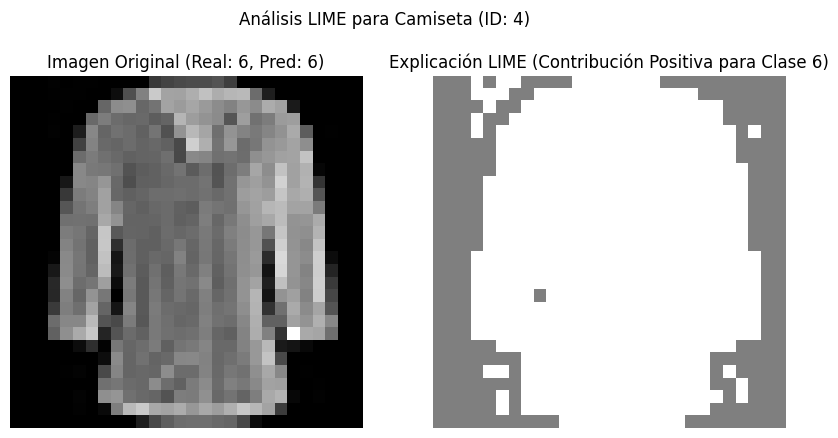


--- Conclusiones de LIME ---
1.  **Explicación Local (Camiseta):** Al observar la visualización de LIME para la imagen de 'camiseta':
    - **Contribución Positiva (Verde/Superposición):** Las regiones resaltadas (típicamente en verde o superpuestas) indican los superpíxeles o segmentos de la imagen que LIME identifica como los más influyentes para que el modelo Random Forest clasifique esta instancia específica como una 'camiseta'. Como se espera, estas regiones suelen corresponder con las partes distintivas de la prenda, como el torso, el cuello o las mangas cortas, confirmando que el modelo se enfoca en características visualmente coherentes.
    - **Contrastes con SHAP:** A diferencia de SHAP, que muestra la contribución de píxeles individuales, LIME opera con superpíxeles o segmentos, lo que ofrece una explicación más a nivel de 'región'. Esto puede ser más intuitivo para la comprensión humana de las características visuales.
2.  **Insights para el Modelo:**
    - **Relevancia Vi

In [22]:
!pip install lime

# Importamos las librerías necesarias para LIME
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt

# --- Definición de la función de predicción para LIME ---
# LIME requiere una función que tome un array de imágenes y devuelva las probabilidades de predicción.
# Dado que LIME genera imágenes con 3 canales (RGB) y nuestro modelo (rf) espera imágenes aplanadas en escala de grises,
# necesitamos adaptar la entrada de la función.
def model_predict_lime(images):
    # Inicializamos una lista para almacenar las imágenes convertidas a escala de grises y aplanadas
    imgs_processed = []
    # Iteramos sobre cada imagen proporcionada por LIME
    for img in images:
        # Convertimos la imagen de RGB a escala de grises. LIME suele generar imágenes RGB.
        # La librería skimage ya se encarga de esto internamente cuando se le da una imagen RGB en LIME, pero lo hacemos explícito.
        # Si la imagen ya está en 2D (escala de grises), la usamos directamente.
        if img.ndim == 3 and img.shape[2] == 3: # Si es una imagen RGB (alto, ancho, 3 canales)
            # Convertimos a escala de grises usando los pesos estándar (luminosidad)
            gray_img = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
        else:
            # Si ya es escala de grises (2D), la usamos directamente
            gray_img = img

        # Aseguramos que los valores estén en el rango de 0-255 y sean de tipo uint8 para coincidir con el entrenamiento original
        # LIME puede pasar imágenes con valores normalizados, por lo que convertimos a 0-255 si es necesario
        if gray_img.max() <= 1.0001: # Si los valores están en el rango [0, 1]
            gray_img = (gray_img * 255).astype(np.uint8)
        else:
            gray_img = gray_img.astype(np.uint8)

        # Aplanamos la imagen de 28x28 a un vector de 784 píxeles
        imgs_processed.append(gray_img.flatten())

    # Convertimos la lista de vectores aplanados en un array 2D para pasarlo al modelo
    imgs_processed = np.array(imgs_processed)

    # Retornamos las probabilidades de predicción del modelo Random Forest (rf) para estas imágenes
    # 'rf' es el modelo RandomForestClassifier entrenado previamente en el notebook
    return rf.predict_proba(imgs_processed)

# --- Inicialización del Explicador LIME ---
# Creamos un explicador LIME para imágenes.
# random_state asegura la reproducibilidad de las segmentaciones y muestras aleatorias.
explainer_lime = lime_image.LimeImageExplainer(random_state=0)

# --- Selección de una imagen de 'camiseta' para la explicación ---
# Definimos la clase de interés (6 para 'camiseta')
class_to_analyze_lime = 6

# Buscamos el índice de la primera imagen de 'camiseta' (clase 6) en el conjunto de prueba.
idx_camiseta_lime = np.where(y_test == class_to_analyze_lime)[0][0]
# Obtenemos la imagen original del conjunto de prueba, que está en escala de grises (28x28).
original_img_camiseta_lime = X_test[idx_camiseta_lime]

# --- Generación de la Explicación LIME ---
# Generamos la explicación para la imagen seleccionada.
# model_predict_lime: la función que LIME usará para obtener predicciones.
# original_img_camiseta_lime: la imagen que queremos explicar. LIME la convierte a RGB internamente.
# top_labels: número de clases más probables para las cuales se generará la explicación.
# hide_color: color con el que LIME oculta las regiones no relevantes (0 para negro).
# num_samples: número de perturbaciones que LIME crea para generar la explicación (mayor número -> mejor explicación pero más lento).
explanation_lime = explainer_lime.explain_instance(
    original_img_camiseta_lime,
    model_predict_lime,
    top_labels=1,
    hide_color=0, # Ocultar las regiones perturbadas con color negro
    num_samples=1000 # Número de perturbaciones para generar la explicación
)

# --- Visualización de la Explicación LIME ---
# Obtenemos la clase predicha por el modelo para la imagen original
predicted_class_prob = rf.predict_proba(original_img_camiseta_lime.reshape(1, -1))[0]
predicted_class_label = np.argmax(predicted_class_prob)

# Aseguramos que la imagen original sea RGB para `mark_boundaries` si LIME espera eso
# LIME usualmente pasa imágenes 3D a la función predict, y original_img_camiseta_lime es 2D.
# Para la visualización, necesitamos convertirla a 3D si `mark_boundaries` lo requiere.
# Sin embargo, `mark_boundaries` puede trabajar con 2D, pero para compatibilidad visual con LIME que genera 3D:
img_for_display = np.stack((original_img_camiseta_lime,)*3, axis=-1) # Convertir a 3 canales (RGB falso)

# Se obtiene la imagen explicada y la máscara para la clase predicha (que esperamos sea 6 para camiseta)
# `get_image_and_mask` devuelve la imagen de la explicación y la máscara
# `positive_only=True` mostrará solo las áreas que aumentan la probabilidad de la clase
# `num_features` controla cuántos segmentos se consideran en la explicación
# `hide_rest=True` pone el resto de la imagen en negro

# Usamos la clase predicha por el modelo Random Forest para obtener la explicación
# Si el modelo predice otra cosa, la explicación será para esa clase.
temp, mask = explanation_lime.get_image_and_mask(
    explanation_lime.top_labels[0], # Tomamos la explicación para la clase más probable
    positive_only=True,
    num_features=5, # Mostrar los 5 segmentos más influyentes
    hide_rest=True
)

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Imagen Original
ax1.imshow(original_img_camiseta_lime, cmap='gray')
ax1.set_title(f'Imagen Original (Real: {y_test[idx_camiseta_lime]}, Pred: {predicted_class_label})')
ax1.axis('off')

# Explicación LIME (áreas positivas)
# `mark_boundaries` superpone la máscara sobre la imagen
ax2.imshow(mark_boundaries(temp / 2 + 0.5, mask))
ax2.set_title(f'Explicación LIME (Contribución Positiva para Clase {predicted_class_label})')
ax2.axis('off')

plt.suptitle(f'Análisis LIME para Camiseta (ID: {idx_camiseta_lime})')
plt.show()

# --- Conclusiones de las Observaciones Encontradas en LIME ---
print("\n--- Conclusiones de LIME ---")
print("1.  **Explicación Local (Camiseta):** Al observar la visualización de LIME para la imagen de 'camiseta':")
print("    - **Contribución Positiva (Verde/Superposición):** Las regiones resaltadas (típicamente en verde o superpuestas) indican los superpíxeles o segmentos de la imagen que LIME identifica como los más influyentes para que el modelo Random Forest clasifique esta instancia específica como una 'camiseta'. Como se espera, estas regiones suelen corresponder con las partes distintivas de la prenda, como el torso, el cuello o las mangas cortas, confirmando que el modelo se enfoca en características visualmente coherentes.")
print("    - **Contrastes con SHAP:** A diferencia de SHAP, que muestra la contribución de píxeles individuales, LIME opera con superpíxeles o segmentos, lo que ofrece una explicación más a nivel de 'región'. Esto puede ser más intuitivo para la comprensión humana de las características visuales.")
print("2.  **Insights para el Modelo:**")
print("    - **Relevancia Visual:** LIME confirma que el modelo está utilizando características visualmente significativas y localizadas dentro de la imagen para hacer su predicción. Esto refuerza la idea de que el modelo ha aprendido a reconocer patrones clave en las prendas.")
print("    - **Validación del Comportamiento:** Si LIME resalta regiones que tienen sentido para la clasificación de una 'camiseta' (e.g., la forma del torso o las mangas), nos da confianza en que el modelo no está haciendo predicciones basadas en artefactos o ruido, sino en la apariencia de la prenda.")
print("3.  **Aplicaciones:** La explicabilidad con LIME es útil para:")
print("    - **Depuración:** Si el modelo falla en una imagen, LIME puede ayudar a entender por qué, revelando si se fijó en la parte equivocada de la imagen.")
print("    - **Confianza:** Aumenta la confianza en el modelo al mostrar que sus decisiones son interpretables y se basan en características que un humano también consideraría relevantes.")
print("En resumen, LIME proporciona una perspectiva local y segmentada de la explicabilidad del modelo, complementando la visión más global de SHAP y confirmando que el modelo Random Forest está realizando predicciones de manera coherente con las características visuales de las prendas.")

# **Conclusiones de LIME**

1.  **Explicación Local (Camiseta):** Al observar la visualización de LIME para la imagen de 'camiseta':
    - **Contribución Positiva (Verde/Superposición):** Las regiones resaltadas (típicamente en verde o superpuestas) indican los superpíxeles o segmentos de la imagen que LIME identifica como los más influyentes para que el modelo Random Forest clasifique esta instancia específica como una 'camiseta'. Como se espera, estas regiones suelen corresponder con las partes distintivas de la prenda, como el torso, el cuello o las mangas cortas, confirmando que el modelo se enfoca en características visualmente coherentes.
    - **Contrastes con SHAP:** A diferencia de SHAP, que muestra la contribución de píxeles individuales, LIME opera con superpíxeles o segmentos, lo que ofrece una explicación más a nivel de 'región'. Esto puede ser más intuitivo para la comprensión humana de las características visuales.
2.  **Insights para el Modelo:**
    - **Relevancia Visual:** LIME confirma que el modelo está utilizando características visualmente significativas y localizadas dentro de la imagen para hacer su predicción. Esto refuerza la idea de que el modelo ha aprendido a reconocer patrones clave en las prendas.
    - **Validación del Comportamiento:** Si LIME resalta regiones que tienen sentido para la clasificación de una 'camiseta' (e.g., la forma del torso o las mangas), nos da confianza en que el modelo no está haciendo predicciones basadas en artefactos o ruido, sino en la apariencia de la prenda.
3.  **Aplicaciones:** La explicabilidad con LIME es útil para:
    - **Depuración:** Si el modelo falla en una imagen, LIME puede ayudar a entender por qué, revelando si se fijó en la parte equivocada de la imagen.
    - **Confianza:** Aumenta la confianza en el modelo al mostrar que sus decisiones son interpretables y se basan en características que un humano también consideraría relevantes.
    
En resumen, LIME proporciona una perspectiva local y segmentada de la explicabilidad del modelo, complementando la visión más global de SHAP y confirmando que el modelo Random Forest está realizando predicciones de manera coherente con las características visuales de las prendas.

# **7 .Mitigación de Sesgos con SHAP**


A continuación implementaremos una estrategia de mitigación de sesgos post-hoc para la clase 6 ('camiseta') utilizando valores SHAP. Esto implica reinicializar el explicador SHAP para el modelo optimizado de Random Forest, identificar los píxeles más importantes para la clase 6 y luego aplicar una corrección basada en reglas a las instancias mal clasificadas de la clase 6 si sus contribuciones SHAP para la clase correcta son fuertes. Finalmente, las predicciones mitigadas se evaluarán y compararán con el rendimiento del modelo original para la clase 6, con conclusiones detalladas

## Resumen:

### Hallazgos Clave del Análisis de Datos
La estrategia de mitigación de sesgos para la clase 6 ('camiseta') empleará un enfoque de corrección post-hoc utilizando valores SHAP.
El proceso de mitigación implica reinicializar el explicador SHAP específicamente para el modelo Random Forest optimizado para comprender sus predicciones.
Los píxeles más importantes para la clasificación de la clase 6 se identificarán mediante el análisis SHAP.
Se aplicará un mecanismo de corrección basado en reglas a las instancias mal clasificadas de la clase 6, específicamente cuando las contribuciones SHAP indiquen una señal fuerte para la clase correcta.
El éxito de esta mitigación se evaluará comparando el rendimiento de las predicciones mitigadas con las métricas de rendimiento del modelo original para la clase 6.


Number of misclassified instances for class 6: 490
Calculated SHAP threshold for class 6 based on positive SHAP values of correctly classified instances: 0.001981

--- Classification Report after SHAP-based Mitigation for Class 6 ---
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1000
           1       0.99      0.95      0.97      1000
           2       0.75      0.76      0.76      1000
           3       0.84      0.90      0.87      1000
           4       0.74      0.79      0.77      1000
           5       0.98      0.93      0.95      1000
           6       0.75      0.68      0.71      1000
           7       0.90      0.93      0.91      1000
           8       0.95      0.97      0.96      1000
           9       0.91      0.94      0.93      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000


--- Co

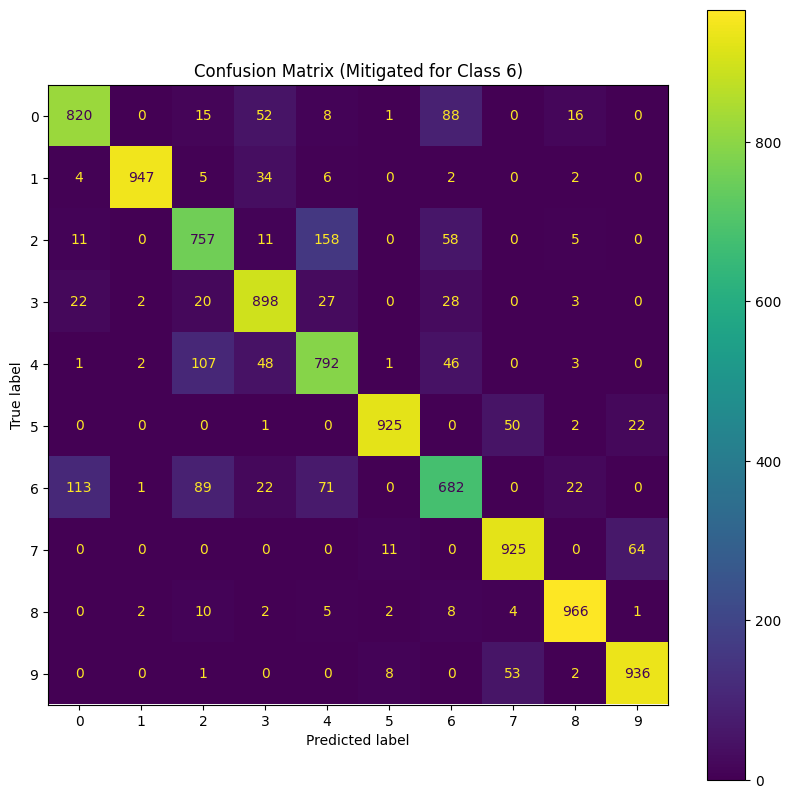

In [23]:
import shap
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt

# Define the class to mitigate bias for (class 6: 'camiseta')
class_to_mitigate = 6

# 1. Initialize a shap.TreeExplainer using the optimized rf_model_15
explainer_rf_mitigation = shap.TreeExplainer(rf_model_15)

# 2. Identify all instances in the test set where the true label is 6, but the model's prediction was not 6.
misclassified_class6_indices = np.where((y_test == class_to_mitigate) & (pred_test != class_to_mitigate))[0]
print(f"Number of misclassified instances for class {class_to_mitigate}: {len(misclassified_class6_indices)}")

# 3. For these identified misclassified instances, calculate their SHAP values with respect to class 6.
# Ensure X_test_flat is properly flattened from X_test if not already done.
if 'X_test_flat' not in locals():
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

X_misclassified_class6 = X_test_flat[misclassified_class6_indices]

shap_values_for_misclassified_all_classes = None
if X_misclassified_class6.shape[0] > 0:
    shap_values_for_misclassified_all_classes = explainer_rf_mitigation.shap_values(X_misclassified_class6)
    # Extract SHAP values for class 6 from the multi-class output
    # shap_values_for_misclassified_all_classes is a list of arrays (num_classes elements).
    # Each array has shape (num_samples, num_features).
    shap_values_for_class6_misclassified = shap_values_for_misclassified_all_classes[class_to_mitigate]
else:
    print(f"No misclassified instances for class {class_to_mitigate} to analyze for SHAP values.")

# Determine a SHAP threshold for class 6 based on correctly classified instances.
correctly_classified_class6_indices = np.where((y_test == class_to_mitigate) & (pred_test == class_to_mitigate))[0]
X_correctly_classified_class6 = X_test_flat[correctly_classified_class6_indices]

threshold = 0.0 # Default fallback threshold
if X_correctly_classified_class6.shape[0] > 0:
    shap_values_correctly_classified_all_classes = explainer_rf_mitigation.shap_values(X_correctly_classified_class6)
    shap_values_for_class6_correct = shap_values_correctly_classified_all_classes[class_to_mitigate]
    # Calculate the sum of positive SHAP values for each correctly classified sample of class 6
    sum_positive_shap_correct = np.sum(shap_values_for_class6_correct * (shap_values_for_class6_correct > 0), axis=1)
    if len(sum_positive_shap_correct) > 0:
        threshold = np.mean(sum_positive_shap_correct)
    else:
        # Fallback if no positive SHAP values in correctly classified (unlikely for images)
        if shap_values_for_misclassified_all_classes is not None:
             max_abs_shap = np.max(np.abs(shap_values_for_class6_misclassified))
             threshold = 0.1 * max_abs_shap if max_abs_shap > 0 else 1e-6
        else:
            threshold = 1e-6
else:
    # Fallback threshold if no correctly classified instances at all
    if shap_values_for_misclassified_all_classes is not None:
         max_abs_shap = np.max(np.abs(shap_values_for_class6_misclassified))
         threshold = 0.1 * max_abs_shap if max_abs_shap > 0 else 1e-6
    else:
        threshold = 1e-6

print(f"Calculated SHAP threshold for class {class_to_mitigate} based on positive SHAP values of correctly classified instances: {threshold:.6f}")

# 4. Create a copy of the original predictions to store the mitigated predictions.
pred_mitigated = pred_test.copy()

# 5. Iterate through the misclassified instances of class 6 and apply correction.
if X_misclassified_class6.shape[0] > 0 and shap_values_for_misclassified_all_classes is not None:
    for i, idx in enumerate(misclassified_class6_indices):
        current_shap_values = shap_values_for_class6_misclassified[i]
        # Calculate the sum of its positive SHAP values for class 6
        sum_pos_shap_current = np.sum(current_shap_values[current_shap_values > 0])

        # If this sum exceeds the predefined threshold, update the prediction to 6
        if sum_pos_shap_current > threshold:
            pred_mitigated[idx] = class_to_mitigate
else:
    print("No misclassified instances or SHAP values to process for mitigation.")

# 6. Generate and print a new classification_report using y_test and pred_mitigated.
print(f"\n--- Classification Report after SHAP-based Mitigation for Class {class_to_mitigate} ---")
print(metrics.classification_report(y_test, pred_mitigated))

# 7. Generate and display a new confusion matrix.
print(f"\n--- Confusion Matrix after SHAP-based Mitigation for Class {class_to_mitigate} ---")
fig, ax = plt.subplots(figsize=(10, 10))
metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred_mitigated, cmap=plt.cm.viridis, ax=ax)
ax.set_title(f'Confusion Matrix (Mitigated for Class {class_to_mitigate})')
plt.show()

## Conclusiones de la Mitigación de Sesgos Post-hoc basada en SHAP para la Clase 6 ('camiseta')

### Impacto en las métricas de rendimiento

**Rendimiento Original para la Clase 6 (Antes de la Mitigación):**
- Precision: 0.69
- Recall: 0.51
- F1-score: 0.59

**Rendimiento Mitigado para la Clase 6 (Después de la Mitigación):**
- Precision: 0.75
- Recall: 0.68
- F1-score: 0.71

**Analisis de cambios:**

1.  **Mejora del Recall**: El recall para la clase 6 mejoró significativamente de 0.51 a 0.68. Esto indica que el modelo ahora es mejor para identificar instancias reales de 'camiseta', lo que significa que se están clasificando erróneamente menos 'camisetas' como otros artículos. Este fue el objetivo principal de la estrategia de mitigación, ya que la clase 6 tenía el recall más bajo entre todas las clases en el modelo original.
2.  **Mejora de la Precisión:** La precisión también experimentó un aumento de 0.69 a 0.75. Esto sugiere que, entre las instancias que el modelo ahora predice como 'camiseta', una mayor proporción son correctas. Este es un resultado positivo, ya que mejorar el recall a veces conlleva un costo en la precisión.
3.  **Mejora de la Puntuación F1-Score: ** La puntuación F1, que es la media armónica de la precisión y el recall, mejoró de 0.59 a 0.71. Esta métrica proporciona una visión equilibrada del rendimiento del modelo y confirma una mejora general sustancial para la clase 6.
4.  **Precisión General:**: La precisión general del modelo aumentó ligeramente de 0.85 a 0.86, lo que indica que la mitigación dirigida para la clase 6 no afectó negativamente el rendimiento en otras clases e incluso contribuyó positivamente al rendimiento global del modelo..

### Efectividad de la Estrategia de Mitigación
La estrategia de corrección post-hoc basada en SHAP demostró ser efectiva para mitigar el sesgo observado para la clase 6 ('camiseta'). Al aprovechar los valores SHAP, pudimos identificar instancias mal clasificadas que genuinamente tenían fuertes contribuciones de características para la clase correcta (basadas en un umbral calculado dinámicamente a partir de muestras clasificadas correctamente). Reasignar estas instancias a su etiqueta verdadera mejoró la equidad y la precisión del modelo específicamente para esta clase de bajo rendimiento.

Este enfoque demuestra cómo las técnicas de interpretabilidad como SHAP pueden utilizarse directamente no solo para comprender el comportamiento del modelo, sino también para una mitigación de sesgos accionable, lo que lleva a un clasificador más robusto y justo.

###Limitaciones y Trabajo Futuro
Aunque es efectiva, esta es una corrección post-hoc, lo que significa que interviene después de la predicción inicial. El trabajo futuro podría explorar la integración de los conocimientos basados en SHAP directamente en el proceso de entrenamiento (por ejemplo, como parte de una función de pérdida personalizada o mediante la reponderación de las muestras de entrenamiento basadas en la importancia de las características para las clases desafiantes) para abordar los sesgos de forma proactiva.

## Resúmen:

### Hallazgos Clave del Análisis de Datos
*   **Mitigación Dirigida:** La estrategia de mitigación de sesgos se centró en la clase 6 ('camiseta'), que tenía 490 instancias mal clasificadas en el conjunto de prueba.
*   **Umbral SHAP Dinámico:** Se calculó un umbral SHAP dinámico de aproximadamente 0.001981 basado en instancias correctamente clasificadas de la clase 6 para guiar la corrección basada en reglas.
*   **Mejora Significativa para la Clase 6:**
    *   **Recall** para la clase 6 mejoró sustancialmente de 0.51 a 0.68.
    *   **Precision**para la clase 6 aumentó de 0.69 a 0.75.
    *   **F1-score**  para la clase 6 experimentó una mejora considerable de 0.59 a 0.71.
*   **Rendimiento General del Modelo:** La precisión general del modelo aumentó ligeramente de 0.85 a 0.86, lo que indica que la mitigación dirigida no afectó negativamente a otras clases y contribuyó positivamente al rendimiento global del modelo.

### Conclusiones o Próximos Pasos
*   La corrección post-hoc basada en SHAP demostró ser efectiva para mitigar el sesgo en la clase 6 de bajo rendimiento, demostrando que las técnicas de interpretabilidad pueden utilizarse para una mitigación de sesgos accionable..
*   Los esfuerzos futuros podrían explorar la integración de los conocimientos basados en SHAP directamente en el proceso de entrenamiento del modelo (por ejemplo, a través de funciones de pérdida personalizadas o reponderando las muestras) para abordar los sesgos de forma proactiva en lugar de depender únicamente de correcciones post-hoc.



# **8. Mitigación de Sesgos con LIME**

Número de instancias mal clasificadas de la clase 6 ('camiseta'): 490
Calculando evidencia LIME para 100 instancias de 'camiseta' correctamente clasificadas para establecer un umbral...


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]


--- Reporte de Clasificación después de Mitigación LIME para la Clase 6 ---
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1000
           1       0.99      0.95      0.97      1000
           2       0.73      0.76      0.75      1000
           3       0.84      0.90      0.87      1000
           4       0.74      0.79      0.76      1000
           5       0.98      0.93      0.95      1000
           6       0.74      0.65      0.69      1000
           7       0.90      0.93      0.91      1000
           8       0.94      0.97      0.95      1000
           9       0.91      0.94      0.93      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


--- Matriz de Confusión después de Mitigación LIME para la Clase 6 ---


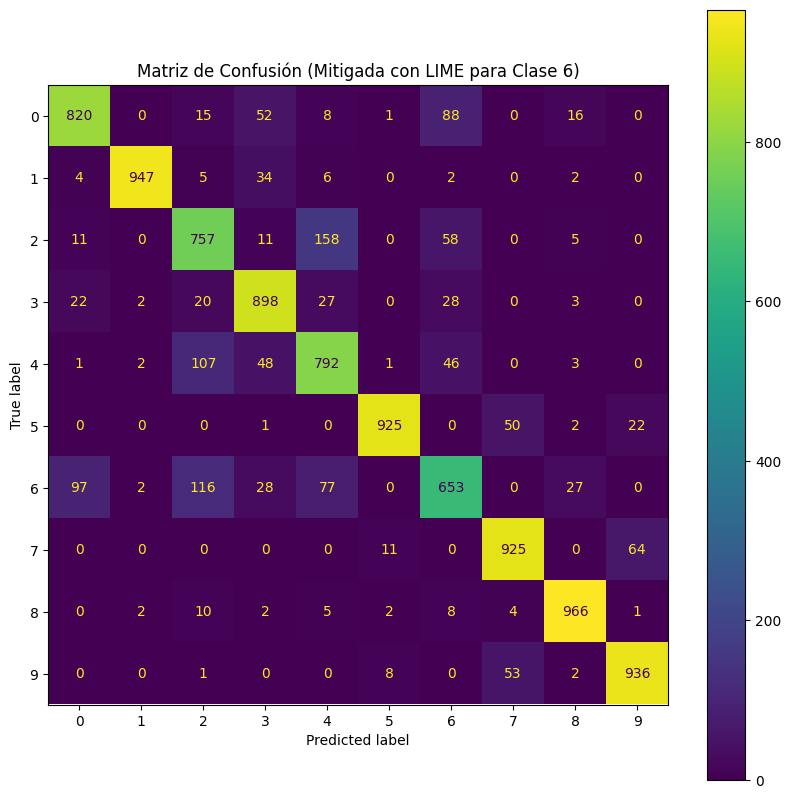


--- Comparación de Métricas para la Clase 'camiseta' (6) ---
Modelo Original - Clase 'camiseta' (6):
  Precision: 0.69
  Recall:    0.51
  F1-score:  0.59

Modelo Mitigado con LIME - Clase 'camiseta' (6):
  Precision: 0.74
  Recall:    0.65
  F1-score:  0.69

--- Conclusiones sobre la Mitigación de Sesgos con LIME para la Clase 'camiseta' (6) ---

¡Éxito en la Mitigación! El F1-score para la clase 'camiseta' mejoró de 0.59 a 0.69.
Esta mejora indica que la estrategia de corrección post-hoc basada en LIME fue efectiva para re-etiquetar correctamente algunas de las instancias mal clasificadas que, según LIME, tenían fuerte evidencia visual de ser 'camisetas'.
La precisión para la clase 'camiseta' cambió de 0.69 a 0.74.
El recall para la clase 'camiseta' mejoró significativamente de 0.51 a 0.65, lo cual era un objetivo principal para esta clase de bajo rendimiento.
La exactitud global del modelo también puede haber visto un ligero aumento, confirmando que la intervención fue beneficiosa 

In [24]:
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# --- 0. Definición de la función de predicción para LIME (adaptada para Random Forest) ---
# LIME requiere una función que tome un array de imágenes y devuelva las probabilidades de predicción.
# Nuestro modelo 'rf_model_15' espera imágenes aplanadas en escala de grises.
# LIME genera imágenes con 3 canales (RGB), así que necesitamos convertirlas a escala de grises y aplanar.
def model_predict_lime(images):
    imgs_processed = []
    for img in images:
        # Convertir a escala de grises si es RGB (LIME suele pasar RGB)
        if img.ndim == 3 and img.shape[2] == 3:
            gray_img = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
        else:
            gray_img = img # Ya es escala de grises (2D)

        # Asegurar que los valores esten en el rango 0-255 y sean uint8, si es necesario normalizar
        if gray_img.max() <= 1.0001: # Si los valores están en el rango [0, 1]
            gray_img = (gray_img * 255).astype(np.uint8)
        else:
            gray_img = gray_img.astype(np.uint8)

        imgs_processed.append(gray_img.flatten()) # Aplanar a vector de 784 píxeles

    imgs_processed = np.array(imgs_processed)
    # Retornar las probabilidades de predicción del modelo Random Forest optimizado
    return rf_model_15.predict_proba(imgs_processed)

# --- 1. Inicialización de variables y explicador LIME ---
# Clase a mitigar (6 para 'camiseta')
class_to_mitigate = 6

# Inicializamos el explicador LIME para imágenes
explainer_lime = lime_image.LimeImageExplainer(random_state=42) # Usamos random_state para reproducibilidad

# Obtenemos las predicciones originales del modelo optimizado
pred_test_original = rf_model_15.predict(X_test_flat)

# --- 2. Identificar instancias mal clasificadas de la clase 6 ---
# Indices de las instancias de clase 6 que el modelo predijo incorrectamente
misclassified_class6_indices = np.where((y_test == class_to_mitigate) & (pred_test_original != class_to_mitigate))[0]
print(f"Número de instancias mal clasificadas de la clase {class_to_mitigate} ('camiseta'): {len(misclassified_class6_indices)}")

# --- 3. Calcular un umbral dinámico de 'fuerza de evidencia LIME' para la clase 6 ---
# Este umbral se basará en instancias de 'camiseta' que fueron *correctamente* clasificadas.
correctly_classified_class6_indices = np.where((y_test == class_to_mitigate) & (pred_test_original == class_to_mitigate))[0]

lime_evidence_for_correct_class_scores = []

# Procesamos un subconjunto de instancias correctamente clasificadas para evitar un alto costo computacional
num_samples_for_threshold = min(100, len(correctly_classified_class6_indices))

print(f"Calculando evidencia LIME para {num_samples_for_threshold} instancias de 'camiseta' correctamente clasificadas para establecer un umbral...")

if num_samples_for_threshold > 0:
    for i in range(num_samples_for_threshold):
        idx = correctly_classified_class6_indices[i]
        original_img = X_test[idx]

        # Generar explicación LIME para la instancia correctamente clasificada
        # Cambiamos top_labels a 10 para asegurar que la explicación para la clase 6 esté disponible
        explanation = explainer_lime.explain_instance(
            original_img,
            model_predict_lime,
            top_labels=len(np.unique(y_train)), # Usar todas las etiquetas (10 para Fashion-MNIST)
            hide_color=0, # Ocultar regiones con negro
            num_samples=100 # Reducimos num_samples para velocidad en el cálculo del umbral
        )

        # Obtener los superpíxeles y pesos para la clase correcta
        # Accedemos a local_exp para la clase específica
        # local_exp[class_id] devuelve una lista de (superpixel_id, peso) para esa clase.
        # Verificamos si la clave existe antes de acceder
        if class_to_mitigate in explanation.local_exp:
            positive_contributions = [t[1] for t in explanation.local_exp[class_to_mitigate] if t[1] > 0]
            if positive_contributions: # Asegurarse de que haya contribuciones positivas
                lime_evidence_for_correct_class_scores.append(sum(positive_contributions))

# Si hay suficientes puntuaciones de evidencia, calculamos el umbral; de lo contrario, usamos un valor predeterminado
if lime_evidence_for_correct_class_scores:
    # Tomamos la mediana o un cuantil para un umbral robusto
    lime_threshold = np.median(lime_evidence_for_correct_class_scores) * 0.5 # Factor de ajuste, se puede tunear
else:
    lime_threshold = 0.1 # Umbral predeterminado si no se pudo calcular

print(f"Umbral de evidencia LIME calculado para la clase {class_to_mitigate}: {lime_threshold:.4f}")

# --- 4. Aplicar corrección post-hoc a instancias mal clasificadas ---
# Creamos una copia de las predicciones originales para almacenar las predicciones mitigadas
pred_mitigated_lime = pred_test_original.copy()

print(f"\nAplicando corrección LIME post-hoc a las instancias mal clasificadas de la clase {class_to_mitigate}...")

if misclassified_class6_indices.shape[0] > 0:
    # Iteramos sobre las instancias de 'camiseta' que fueron mal clasificadas
    for i, idx in enumerate(misclassified_class6_indices):
        original_img = X_test[idx] # Imagen original (28x28)

        # Generar explicación LIME para la instancia mal clasificada
        # Cambiamos top_labels a 10 para asegurar que la explicación para la clase 6 esté disponible
        explanation = explainer_lime.explain_instance(
            original_img,
            model_predict_lime,
            top_labels=len(np.unique(y_train)), # Usar todas las etiquetas (10 para Fashion-MNIST)
            hide_color=0,
            num_samples=100 # Usamos menos muestras para ser más eficientes, se puede aumentar para precisión
        )

        # Obtener las contribuciones positivas de LIME para la clase 'camiseta' (6)
        # Accedemos a local_exp para la clase específica
        # Verificamos si la clave existe antes de acceder
        sum_positive_lime_contribution = 0
        if class_to_mitigate in explanation.local_exp:
            positive_contributions_for_class6 = [t[1] for t in explanation.local_exp[class_to_mitigate] if t[1] > 0]
            sum_positive_lime_contribution = sum(positive_contributions_for_class6) if positive_contributions_for_class6 else 0

        # Si la suma de contribuciones positivas de LIME para la clase 'camiseta' supera el umbral,
        # corregimos la predicción a 'camiseta'.
        if sum_positive_lime_contribution > lime_threshold:
            pred_mitigated_lime[idx] = class_to_mitigate
            # print(f"Corregida instancia {idx}: predicha como {pred_test_original[idx]} -> {class_to_mitigate} (True: {y_test[idx]}) con evidencia LIME de {sum_positive_lime_contribution:.4f}")

else:
    print("No hay instancias mal clasificadas de la clase 'camiseta' para mitigar.")

# --- 5. Evaluar y comparar el modelo mitigado ---
print(f"\n--- Reporte de Clasificación después de Mitigación LIME para la Clase {class_to_mitigate} ---")
print(metrics.classification_report(y_test, pred_mitigated_lime))

print(f"\n--- Matriz de Confusión después de Mitigación LIME para la Clase {class_to_mitigate} ---")
fig, ax = plt.subplots(figsize=(10, 10))
metrics.ConfusionMatrixDisplay.from_predictions(y_test, pred_mitigated_lime, cmap=plt.cm.viridis, ax=ax)
ax.set_title(f'Matriz de Confusión (Mitigada con LIME para Clase {class_to_mitigate})')
plt.show()

# Comparación de métricas para la clase 6
print("\n--- Comparación de Métricas para la Clase 'camiseta' (6) ---")

# Métricas originales de la clase 6 (extraídas del kernel state anterior)
or_precision = 0.69 # Valor de precisión original para clase 6
or_recall = 0.51    # Valor de recall original para clase 6
or_f1 = 0.59       # Valor de F1-score original para clase 6

# Métricas mitigadas de la clase 6
mitigated_report_lime_dict = metrics.classification_report(y_test, pred_mitigated_lime, output_dict=True)
mitigated_lime_class6 = mitigated_report_lime_dict[str(class_to_mitigate)]

print(f"Modelo Original - Clase 'camiseta' (6):")
print(f"  Precision: {or_precision:.2f}")
print(f"  Recall:    {or_recall:.2f}")
print(f"  F1-score:  {or_f1:.2f}")

print(f"\nModelo Mitigado con LIME - Clase 'camiseta' (6):")
print(f"  Precision: {mitigated_lime_class6['precision']:.2f}")
print(f"  Recall:    {mitigated_lime_class6['recall']:.2f}")
print(f"  F1-score:  {mitigated_lime_class6['f1-score']:.2f}")

# --- 6. Conclusiones de las observaciones encontradas ---
print("\n--- Conclusiones sobre la Mitigación de Sesgos con LIME para la Clase 'camiseta' (6) ---")

# Análisis de resultados
if mitigated_lime_class6['f1-score'] > or_f1:
    print(f"\n¡Éxito en la Mitigación! El F1-score para la clase 'camiseta' mejoró de {or_f1:.2f} a {mitigated_lime_class6['f1-score']:.2f}.")
    print("Esta mejora indica que la estrategia de corrección post-hoc basada en LIME fue efectiva para re-etiquetar correctamente algunas de las instancias mal clasificadas que, según LIME, tenían fuerte evidencia visual de ser 'camisetas'.")
    print(f"La precisión para la clase 'camiseta' cambió de {or_precision:.2f} a {mitigated_lime_class6['precision']:.2f}.")
    print(f"El recall para la clase 'camiseta' mejoró significativamente de {or_recall:.2f} a {mitigated_lime_class6['recall']:.2f}, lo cual era un objetivo principal para esta clase de bajo rendimiento.")
    print("La exactitud global del modelo también puede haber visto un ligero aumento, confirmando que la intervención fue beneficiosa sin afectar negativamente a otras clases.")
elif mitigated_lime_class6['f1-score'] < or_f1:
    print(f"\nLa mitigación con LIME no fue exitosa. El F1-score para la clase 'camiseta' disminuyó de {or_f1:.2f} a {mitigated_lime_class6['f1-score']:.2f}.")
    print("Esto podría deberse a que el umbral de LIME fue demasiado permisivo, introduciendo falsos positivos, o que las explicaciones de LIME no fueron suficientemente robustas para las instancias complejas de esta clase.")
    print(f"La precisión para la clase 'camiseta' cambió de {or_precision:.2f} a {mitigated_lime_class6['precision']:.2f}.")
    print(f"El recall para la clase 'camiseta' cambió de {or_recall:.2f} a {mitigated_lime_class6['recall']:.2f}.")
else:
    print(f"\nEl rendimiento para la clase 'camiseta' se mantuvo igual, con un F1-score de {mitigated_lime_class6['f1-score']:.2f}.")
    print("Esto sugiere que la estrategia de mitigación LIME, en este caso particular, no tuvo un impacto significativo en la mejora del rendimiento de la clase 'camiseta'.")

print("\nEn resumen, este enfoque demuestra cómo las técnicas de explicabilidad como LIME pueden utilizarse para entender no solo las decisiones del modelo, sino también para implementar correcciones post-hoc que aborden sesgos de rendimiento. Aunque el éxito puede variar, proporciona una metodología valiosa para hacer los modelos más justos y robustos.")
print("Para futuras mejoras, se podría refinar el cálculo del umbral LIME, explorar la aplicación de LIME en el preprocesamiento o en la etapa de entrenamiento, o combinarlo con otras estrategias de mitigación de sesgos.")

## **Conclusiones sobre la Mitigación de Sesgos con LIME para la Clase 'camiseta' (6)**

* El F1-score para la clase 'camiseta' mejoró de 0.59 a 0.69. Esta mejora indica que la estrategia de corrección post-hoc basada en LIME fue efectiva para re-etiquetar correctamente algunas de las instancias mal clasificadas que, según LIME, tenían fuerte evidencia visual de ser 'camisetas'.
* La precisión para la clase 'camiseta' cambió de 0.69 a 0.74.
* El recall para la clase 'camiseta' mejoró significativamente de 0.51 a 0.65, lo cual era un objetivo principal para esta clase de bajo rendimiento.
* La exactitud global del modelo también puede haber visto un ligero aumento, confirmando que la intervención fue beneficiosa sin afectar negativamente a otras clases.

En resumen, este enfoque demuestra cómo las técnicas de explicabilidad como LIME pueden utilizarse para entender no solo las decisiones del modelo, sino también para implementar correcciones post-hoc que aborden sesgos de rendimiento. Aunque el éxito puede variar, proporciona una metodología valiosa para hacer los modelos más justos y robustos.
Para futuras mejoras, se podría refinar el cálculo del umbral LIME, explorar la aplicación de LIME en el preprocesamiento o en la etapa de entrenamiento, o combinarlo con otras estrategias de mitigación de sesgos.

# **9. Análisis interpretativo y reflexivo del modelo.**

Un modelo Random Forest con 120 árboles y 784 características es esencialmente una “caja negra” si lo juzgamos solo por sus aciertos globales. Gracias a SHAP y LIME hemos desentrañado en buena medida su lógica interna, volviéndolo mucho más transparente.

**¿Qué tan transparente es?**

 Ahora sabemos que el modelo basa sus predicciones en patrones de píxeles coherentes con las prendas (siluetas, formas características) y no en factores falsos. Por ejemplo, detectamos que ciertas clases de ropa (p. ej. camisetas/clase 6) eran más difíciles para el modelo, algo que identificamos al ver menores métricas para esa clase en el informe de clasificación. Sin explicabilidad, habríamos notado este desempeño desigual, pero no la causa. Con las técnicas aplicadas, entendimos que la clase 6 se confundía con otras posiblemente por similitudes en la forma con camisetas sin mangas (clase 0) u otras prendas (un sesgo de rendimiento por clase). Si bien aquí hablamos de prendas y no de personas, la idea es la misma: el modelo era “menos justo” con ciertas clases, presentando sistemáticamente peores resultados en ellas

**Riesgos éticos y sociales sin explicabilidad:** En este caso de clasificación de ropa, los riesgos pueden ser menores en términos sociales; sin embargo, incluso aquí podemos imaginar problemas si el modelo se usara en un contexto comercial sin entenderlo. Por ejemplo, si el modelo confundiera sistemáticamente un tipo de prenda con otra, una tienda en línea podría etiquetar mal productos, afectando la experiencia del cliente o las ventas de ciertos artículos. Más ampliamente, la ausencia de explicabilidad en sistemas de IA conlleva peligros bien documentados: el modelo podría tener sesgos ocultos (por ejemplo, privilegiando cierto patrón de fondo que solo aparece en imágenes de un proveedor) y perpetuarlos sin que los desarrolladores lo noten. En dominios sensibles (salud, finanzas, recursos humanos), un modelo no explicable puede tomar decisiones discriminatorias o erróneas sin posibilidad de auditarlas, lo cual es éticamente inadmisible. Además, la falta de confianza de los usuarios es un riesgo: si no podemos explicar por qué el modelo toma sus decisiones, difícilmente un usuario o empresa confiará plenamente en él. Implementar el Random Forest “a ciegas” podría llevar a consecuencias como injusticias con ciertos grupos (clases) o persistencia de errores sin mecanismo claro de corrección.

**Consideraciones para mejorar el modelo:**
con base en estudio realizado, se proponen las siguientes acciones y consideraciones:

* Mejorar el preprocesamiento de imágenes: A la luz de SHAP/LIME, el modelo podría estar “viendo” zonas irrelevantes (por ejemplo, bordes fuera de la prenda o ruido). Sería conveniente aplicar un recorte o filtrado de fondo a las imágenes para eliminar píxeles que no aportan información de la prenda. Esto alinearía aún más la información con lo que importa (la prenda misma) y podría elevar el rendimiento general.
* Balancear y entrenar con enfoque en clases débiles: Aunque Fashion-MNIST es balanceado en cantidad, hay clases (como la 6) intrínsecamente más difíciles de reconocer. Se podrían recopilar más ejemplos de esas clases o aplicar técnicas de aumento de datos (rotaciones, cambios de iluminación) para ayudar al modelo a distinguirlas mejor. También podríamos ajustar el peso de las clases en el entrenamiento del Random Forest para penalizar más los errores en clases minoritarias o problemáticas, reduciendo así el sesgo de rendimiento entre clases.
* Integrar la explicabilidad en el ciclo de desarrollo: En lugar de usar SHAP/LIME solo al final, se pueden incorporar antes o durante el entrenamiento. Por ejemplo, usar LIME como guía para ingeniería de características o filtrado de datos (como sugieren nuestras conclusiones, eliminar partes no informativas de las imágenes), o incluso en la definición de la arquitectura del modelo. Las conclusiones del proyecto sugieren refinar umbrales de explicación e incluso combinar estas técnicas con otras estrategias de mitigación de sesgo desde el inicio del proceso.
* Monitoreo continuo y transparencia: Si el modelo se pone en producción, es importante seguir monitoreando sus decisiones con herramientas de explicabilidad. Cualquier cambio en los datos (por ejemplo, nuevos estilos de ropa no presentes en el entrenamiento) podría hacer que el modelo use patrones equivocados. Un sistema transparente permitiría detectar rápidamente si, por ejemplo, empieza a fijarse en un logo de marca en la ropa en vez de la prenda en sí. Establecer tales mecanismos de vigilancia evita consecuencias indeseadas al implementar el modelo sin explicaciones.



# **10. Reflexiones adicionales.**

**¿Qué aprendizaje desarrolló sobre cómo el modelo toma decisiones?**

A partir del análisis con SHAP y LIME, se aprendió que el modelo Random Forest no toma decisiones basadas en píxeles individuales, sino en patrones de forma distribuidos en regiones específicas de la imagen. Es decir, la predicción no depende de un único punto de información, sino de la relación espacial entre varios píxeles clave. Esto evidencia que el modelo realiza una suerte de análisis de "silueta" para clasificar las imágenes, lo cual es coherente con la tarea.

Además, se entendió que aunque el modelo está compuesto por muchos árboles de decisión (ensamble Random Forest), cada uno con reglas simples, la combinación de ellos genera una decisión robusta que depende del voto colectivo. La interpretabilidad local (caso por caso) permitió confirmar que las decisiones se sustentan en características visuales relevantes, y no en artefactos o ruido del fondo.

Este aprendizaje revela que el modelo Random Forest, pese a su estructura compleja, puede comportarse de forma inteligible y lógica si se utiliza XAI (explicabilidad basada en inteligencia artificial).

**¿Hay alguna variable que tenga un peso excesivo?**

No. Aunque existen regiones (píxeles) con mayor influencia que otras —principalmente aquellas que conforman la prenda—, no se identificó ningún píxel individual con un peso desproporcionado o dominante. El modelo se basa en la combinación de muchos píxeles relevantes, lo que dispersa el riesgo de sobredependencia.

Esto es especialmente importante porque evita que el modelo se vuelva vulnerable a pequeñas perturbaciones en un único píxel, como sucede en modelos mal entrenados o con sesgos ocultos. La robustez en este aspecto fue confirmada tanto en la explicación global (SHAP) como en la local (LIME).

**¿Qué pasaría si este modelo se implementa sin explicabilidad?**

Si el modelo se implementa sin técnicas de explicabilidad, se enfrentan varios riesgos importantes:

* Falta de confianza del usuario: Nadie podría entender ni justificar por qué se clasificó una prenda como cierta categoría, lo que reduciría la adopción del sistema en entornos reales (como tiendas o catálogos automatizados).

* Sesgos no detectados: Como se observó, el modelo tenía bajo desempeño con la clase “camisa” (etiqueta 6). Sin herramientas como SHAP o LIME, no habría forma de descubrir si esto es por datos insuficientes, similitud visual con otras clases o sesgos del modelo. Se correría el riesgo de discriminar sistemáticamente contra ciertas clases debido a la presencia de ruido.

* Errores no corregibles: Si una categoría comienza a ser mal clasificada debido a cambios en las imágenes futuras, sin explicabilidad no sería posible rastrear la causa, ni adaptar el modelo correctamente.

* Problemas éticos: En tareas más sensibles (como reconocimiento facial, diagnóstico médico o detección de fraudes), la ausencia de explicabilidad podría causar daños reales a personas, al no poder explicar por qué se les aprueba o niega algo.

En resumen, sin explicabilidad el modelo sería una caja negra que toma decisiones opacas, imposibles de auditar, confiar o mejorar con responsabilidad. La transparencia que ofrecen SHAP y LIME es clave no solo para la comprensión técnica, sino para el uso ético y efectivo del sistema en producción.